# Make concept plots for Patatrack Pixel Tracking

In [1]:
# import packages
import uproot
import awkward as ak
import vector
vector.register_awkward()
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.patches import Arc
import numpy as np
from scipy.stats import binomtest
from sakura import setStyle, cmslabel, savefig, lumilabel, xlabel, ylabel
from simplotter.utils.markLayers import markLayersXY
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
setStyle()

from itertools import cycle
prop_cycle = plt.rcParams['axes.prop_cycle']
colorsOG = cycle(prop_cycle.by_key()['color'])

colors = sns.color_palette("Set2", 31)
colorsIT = cycle(colors)

In [2]:
#datafile = "data/pixelTrackNtuples_TTbar_200PU_1evt.root"
datafile = "data/pixelTrackNtuples_TTbar_noPU_1evt.root"

inputFile = uproot.open(datafile)
inputTree = inputFile["pixelTrackNtuplizer/PixelTracks"]

DIR = "plots_CAExtension"

## Classes `Event` and `DoubletCuts` for easier analysis

In [3]:
class Event:
    # Members
    Tracks = None
    RecHits = None
    Vertices = None
    TrackingParticles = None
    BeamSpot = None
    index = 0
    event = 0

    def __init__(self, tree, event=0):
        Data = inputTree.arrays(entry_start = event, entry_stop = event+1)[0]

        # set event, index and BeamSpot
        self.index = event
        self.event = Data.event
        self.BeamSpot = ak.zip({"x" : Data.beamspot_x, 
                                "y" : Data.beamspot_y,
                                "z" : Data.beamspot_z}, with_name="Vector3D")

         # create Tracks
        self.Tracks = ak.zip({
            "hitIds" : ak.unflatten(Data.track_hitIds, Data.track_nHits), 
            "nHits" : Data.track_nHits,
            "nPixelHits" : Data.track_nPixelHits,
            "nLayers" : Data.track_nLayers,
            "isFake" : Data.track_isFake,
            "isSignal" : Data.track_isSignal,
            "eta" : Data.track_eta,
            "phi" : Data.track_phi,
            "pt" : Data.track_pt,
            "tip" : Data.track_tip,
            "zip" : Data.track_zip,
            "qoverp" : Data.track_qoverp,
            "nchi2" : Data.track_nchi2,
            "ndof" : Data.track_ndof,
            "bestVertex" : Data.track_bestVertex,
            "bestVertexWith3Tracks" : Data.track_bestVertexWith3Tracks
        },
        with_name="Momentum3D",
        depth_limit=1)

        # create TrackingParticles
        self.TrackingParticles = ak.zip({
            "hitIds" : ak.unflatten(Data.trackingParticle_hitIds, Data.trackingParticle_nHits), 
            "nHits" : Data.trackingParticle_nHits,
            "nLayers" : Data.trackingParticle_nLayers,
            "isMissed" : Data.trackingParticle_isMissed,
            "isSignal" : Data.trackingParticle_isSignal,
            "isIntime" : Data.trackingParticle_isIntime,
            "pid" : Data.trackingParticle_pid,
            "eta" : Data.trackingParticle_eta,
            "phi" : Data.trackingParticle_phi,
            "pt" : Data.trackingParticle_pt,
            "vx" : Data.trackingParticle_x,
            "vy" : Data.trackingParticle_y,
            "vz" : Data.trackingParticle_z,
            "charge" : Data.trackingParticle_charge
        },
        with_name="Momentum3D",
        depth_limit=1)

        # create RecHits
        self.RecHits = ak.zip({
            "x" : Data.recHit_x, 
            "y" : Data.recHit_y,
            "z" : Data.recHit_z,
            "detId" : Data.recHit_detId,
            "moduleId" : Data.recHit_moduleId,
            "layerId" : Data.recHit_layerId,
            "trackingParticle" : Data.recHit_trackingParticle
        },
        with_name="Vector3D")

        # create Vertices
        self.Vertices = ak.zip({
            "x" : Data.vertex_x, 
            "y" : Data.vertex_y,
            "z" : Data.vertex_z,
            "nTracks" : Data.vertex_nTracks
        },
        with_name="Vector3D")

    def TrackingParticle(self, i):
        """
        Returns full TrackingParticle including its RecHits.
        """
        
        hitIds = self.TrackingParticles[i].hitIds

        output = ak.zip({k : self.TrackingParticles[i][k] for k in self.TrackingParticles.fields[1:]} | 
                      {"RecHits" : ak.unflatten(self.RecHits[hitIds], len(hitIds))}, 
                      with_name="Momentum3D",
                      depth_limit=1)
        return output if len(hitIds) == 0 else output[0]

    def Track(self, i):
        """
        Returns full Track including its RecHits.
        """
        
        hitIds = self.Tracks[i].hitIds

        return ak.zip({k : self.Tracks[i][k] for k in self.Tracks.fields[1:]} | 
                      {"RecHits" : ak.unflatten(event.RecHits[hitIds], len(hitIds))}, 
                      with_name="Momentum3D",
                      depth_limit=1)[0]

    def TrackWithTPs(self, i):
        """
        Returns full Track including its RecHits as well as the list of 
        TrackingParticles (incl. RecHits) that the Track's hits actually correspond to.
        """
        # get the track
        track = self.Track(i)

        # get the list of TrackingParticles belonging to those hits
        trackingParticles = list(set(track.RecHits.trackingParticle) - {-1})

        # return both the track as well as the TrackingParticles
        return track, [self.TrackingParticle(k) for k in trackingParticles]

    def getTracks(self, mask=None):
        """
        Returns full Tracks including their RecHits.
        """
        # set mask if not given
        mask = ak.ones_like(self.Tracks.nHits, dtype=bool) if mask is None else mask
        
        hitIds = self.Tracks[mask].hitIds

        return ak.zip({k : self.Tracks[mask][k] for k in self.Tracks.fields[1:]} | 
                      {"RecHits" : ak.unflatten(self.RecHits[ak.flatten(hitIds, axis=None)], self.Tracks[mask].nHits)},
                      with_name="Momentum3D",
                      depth_limit=1)

    def fakeTracks(self):
        """
        Returns full fake Tracks including their RecHits.
        """
        mask = self.Tracks.isFake
        return self.getTracks(mask=mask)

    def trueTracks(self):
        """
        Returns full true Tracks including their RecHits.
        """
        mask = ~self.Tracks.isFake
        return self.getTracks(mask=mask)

    def signalTracks(self):
        """
        Returns full true signal Tracks including their RecHits.
        """
        mask = self.Tracks.isSignal
        return self.getTracks(mask=mask)

    def getDoublets(self, innerLayer, outerLayer, mask=None, onlyConsecutive=True):
        """
        Builds RecHit doublets for a given layer pair (innerLayer, outerLayer) from a (masked) Track collection.
        The RecHit positions are corrected for the beamspot internally.
        The onlyConsecutive flag restricts the doublets to consecutive pairs of RecHits when no layer in between was used.
        E.g., a track has hits in layers 1, 2 and 3, and you ask for the doublets in the pair (1,3). If onlyConsecutive==True,
        there will be no doublet built as there is a used layer in between (layer 2). 
        To get all doublets without this restriction, onlyConsecutive must be disabled.
        """
        # set mask if not given
        mask = ak.ones_like(self.Tracks.nHits, dtype=bool) if mask is None else mask

        hitIds = self.Tracks[mask].hitIds
        layerIds = ak.unflatten(self.RecHits.layerId[ak.flatten(hitIds, axis=None)], self.Tracks[mask].nHits)

        if onlyConsecutive:
            # use fact that layerIds are sorted in increasing order by design
            # to find the tracks where the given layer pair is used
            # meaning the corresponding RecHits are consecutive (no other layer in between)
            maskOnTop = ak.any((layerIds == innerLayer)[:, :-1] & (layerIds == outerLayer)[:, 1:], axis=1)
        else:
            # else we just need to check that the given layers are present in the track
            maskOnTop = ak.any(layerIds == innerLayer, axis=1) & ak.any(layerIds == outerLayer, axis=1)
        layerIds = layerIds[maskOnTop]
        hitIds = hitIds[maskOnTop]

        # build combinations of inner, outer layer that are present in reconstructed tracks
        doublets = ak.cartesian({"inner": hitIds[layerIds==innerLayer], "outer": hitIds[layerIds==outerLayer]})
        doublets = ak.flatten(doublets, axis=1)
        
        return ak.zip({inout :
                        ak.zip({k: self.RecHits[doublets[inout]][k] for k in self.RecHits.fields[3:]} | 
                               {k : self.RecHits[doublets[inout]][k] - self.BeamSpot[k] for k in ["x", "y", "z"]},
                               with_name="Vector3D") for inout in ["inner", "outer"]})

    def fakeDoublets(self, innerLayer, outerLayer, onlyConsecutive=True):
        """
        Builds fake RecHit doublets for a given layer pair (innerLayer, outerLayer) from the reconstructed fake Tracks.
        """
        mask = self.Tracks.isFake
        doublets = self.getDoublets(innerLayer, outerLayer, mask=mask, onlyConsecutive=onlyConsecutive)

        # remove those doublets in which both RecHits belong to the same TrackingParticle
        sameTP = (doublets.inner.trackingParticle != -1) & (doublets.inner.trackingParticle == doublets.outer.trackingParticle)
        return doublets[~sameTP] 

    def trueDoublets(self, innerLayer, outerLayer, onlyConsecutive=True):
        """
        Builds true RecHit doublets for a given layer pair (innerLayer, outerLayer) from the reconstructed Tracks.
        """
        mask = ~self.Tracks.isFake
        doublets = self.getDoublets(innerLayer, outerLayer, mask=mask, onlyConsecutive=onlyConsecutive)

        # remove those doublets in which both RecHits belong to the same TrackingParticle
        sameTP = (doublets.inner.trackingParticle != -1) & (doublets.inner.trackingParticle == doublets.outer.trackingParticle)
        return doublets[sameTP] 

    def printStats(self):
        print("General stats\n" + 50*"-")
        print("  #TrackingParticles = %i" % len(self.TrackingParticles))
        print("  #Tracks = %i" % len(self.Tracks))
        print("  #RecHits = %i" % len(self.RecHits))

        sig = self.TrackingParticles.isSignal
        print("\nTrackingParticle stats\n" + 50*"-")
        print("  #signal = %i" % ak.sum(sig))
        print("  #intime = %i" % ak.sum(self.TrackingParticles.isIntime))
        print("\nFull signal phase space:")
        nTot = len(self.TrackingParticles.isMissed[sig])
        nMissed = ak.sum(self.TrackingParticles.isMissed[sig])
        print("  %s(missed) = %i / %i = %.3f" % ("%", nMissed, nTot, nMissed/nTot))
        
        pTmin = 0.9
        mask = sig & (self.TrackingParticles.pt > 0.9)
        print("signal && pT > %.2f:" % pTmin)
        nTot = len(self.TrackingParticles.isMissed[mask])
        nMissed = ak.sum(self.TrackingParticles.isMissed[mask])
        print("  %s(missed) = %i / %i = %.3f" % ("%", nMissed, nTot, nMissed/nTot))
        
        print("\nTracks stats\n" + 50*"-")
        
        nTot = len(self.Tracks.isFake)
        nFake = ak.sum(self.Tracks.isFake)
        print("  %s(fake) = %i / %i = %.3f" % ("%", nFake, nTot, nFake/nTot))
        
        mask = self.Tracks.isFake
        print("  <#hits> (fakes) = %.2f" % (np.mean(self.Tracks.nHits[mask])))
        print("  <#hits> (trues) = %.2f" % (np.mean(self.Tracks.nHits[~mask])))

        print("\nVertices stats\n" + 50*"-")
        mask = event.Tracks.bestVertex == event.Tracks.bestVertexWith3Tracks
        print("  #vertices = %i" % len(event.Vertices))
        print("  #vertices (+3 tracks) = %i" % ak.sum(event.Vertices.nTracks >= 3))
        print("  #tracks with (best vertex == best vertex w/ +3 tracks) = %i" % ak.sum(mask))
        print("  #tracks with (best vertex != best vertex w/ +3 tracks) = %i" % ak.sum(~mask))

In [4]:
class DoubletCuts:
    # Members
    cutsOfPairs = None

    def __init__(self):
        self.cutsOfPairs = {}

    def keyForPair(self, innerLayer, outerLayer):
        return "%i_%i" % (innerLayer, outerLayer)

    def appendCuts(self, newCuts, innerLayer, outerLayer):
        """
        Append doublet cuts newCuts for layer pair (innerLayer, outerLayer) to the respective container.
        If the container does not exist yet, create it.
        """
        key = self.keyForPair(innerLayer, outerLayer)
        
        if key not in self.cutsOfPairs:
            self.cutsOfPairs[key] = newCuts
        else:
            self.cutsOfPairs[key] = ak.concatenate([self.cutsOfPairs[key], newCuts])

    def cuts(self, innerLayer, outerLayer):
        """
        Returns cuts for given layer pair.
        """
        return self.cutsOfPairs[self.keyForPair(innerLayer, outerLayer)]

    def cut(self, cutName, innerLayer=None, outerLayer=None):
        """
        Returns a specific cut cutName either for a given layer pair or 
        for all layer pairs if none are given.
        """
        if (innerLayer is None) or (outerLayer is None):
            return ak.concatenate([self.cutsOfPairs[key][cutName] for key in self.cutsOfPairs.keys()])
        else:
            return self.cutsOfPairs[self.keyForPair(innerLayer, outerLayer)][cutName]

## Helper functions

In [5]:
def split_scientificNotation(n):
    a = '%E' % n
    return float(a.split('E')[0].rstrip('0').rstrip('.')), int(a.split('E')[1])
    
def valToLatexStr(val):
    """
    Transforms a given float/int value into a nice Latex string representation.
    E.g.:
      100000 => "10^{5}"
      5.0 => "5"
      2.3 => "2.3"
      0.134 => "0.13"
      0.00735 => "7.35 \times 10^{-3}"
    """
    # option 1: int or large float
    if isinstance(val, int) or val.is_integer() or (val>100):
        if abs(val) < 10000:
            valStr = "%i" % int(val)
        else:
            coefficient, exponent = split_scientificNotation(val)
            if (coefficient).is_integer():
                valStr = "%i" % coefficient
                if valStr == "1":
                    return r"10^{" + str(exponent) + r"}"
                elif valStr == "-1":
                    return r"-10^{" + str(exponent) + r"}"
            elif (coefficient*10).is_integer():
                valStr = "%.1f" % coefficient
            else:
                valStr = "%.2f" % coefficient
            
            valStr += r"\times 10^{" + str(exponent) + r"}" 
    
    # option 2: float close or larger than 1
    elif abs(val) >= 0.1:
        if (val*10).is_integer():
            valStr = "%.1f" % val
        else:
            valStr = "%.2f" % val

    # option 3: small float
    else:
        coefficient, exponent = split_scientificNotation(val)
        if (coefficient).is_integer():
            valStr = "%i" % coefficient
            if valStr == "1":
                return r"10^{" + str(exponent) + r"}"
            elif valStr == "-1":
                return r"-10^{" + str(exponent) + r"}"
        elif (coefficient*10).is_integer():
            valStr = "%.1f" % coefficient
        else:
            valStr = "%.2f" % coefficient

        valStr += r"\times 10^{" + str(exponent) + r"}" 

    return valStr

def meanStdToLatexStr(mean, std):
    """
    Transforms a given mean-std value pair into a nice Latex string representation.
    E.g.:
      (6.925702811, 0.0321952747) => "6.93 \\pm 0.03"
      (0.000925702811, 0.00000321952747) => "(925.7 \\pm 3.2) \\cdot 10^{-6}"
      (925702811, 95247) => "(92570.3 \\pm 9.5) \\cdot 10^{4}"
      
    """
    coefficient_std, exponent_std = split_scientificNotation(std)
    figures_std = 2 if int(coefficient_std)==1 else 1
    
    coefficient_mean, exponent_mean = split_scientificNotation(mean)
    figures_mean = exponent_mean - exponent_std + figures_std
    
    if (abs(exponent_mean) < 3) or (abs(exponent_std) < 2):
        valStr = '%.*g' % (figures_mean, mean) + r" \pm " + '%.*g' % (figures_std, std)
    else:
        valStr = '(%.*f' % (figures_std, coefficient_mean*10**(exponent_mean-exponent_std)) + r" \pm " + '%.*f)' % (figures_std, coefficient_std) + r" \cdot 10^{" + str(exponent_std) + "}"
    
    return valStr


def approx_atan2s_P7(x):
    z = x * x
    return x * ((-10422.177734375) + z * (3349.97412109375 + z * ((-1525.589599609375) + z * 406.64190673828125)))

def unsafe_atan2s(y, x):
    maxshort = int(32767+1)
    pi4 = int(maxshort / 4)
    pi34 = int(3* maxshort / 4)

    r = (np.abs(x) - np.abs(y)) / (np.abs(x) + np.abs(y))
    
    if (x < 0):
        r = -r
    
    angle = pi4 if (x >= 0) else pi34
    angle += int(approx_atan2s_P7(r))
    
    return -angle if (y < 0) else angle

unsafe_atan2s = np.vectorize(unsafe_atan2s, otypes=[int])

def getDoubletCuts(doublets):
    dr = doublets.outer.rho - doublets.inner.rho
    dphi = np.abs(doublets.inner.deltaphi(doublets.outer))
    curvature = 1 / 2 * np.sqrt((dr / dphi)**2 + (doublets.inner.rho * doublets.outer.rho))
    outer_iphi = unsafe_atan2s(doublets.outer.y, doublets.outer.x)
    inner_iphi = unsafe_atan2s(doublets.inner.y, doublets.inner.x)
    
    return ak.zip({
        "innerZ" : doublets.inner.z,
        "dr" : dr,
        "z0" : np.abs(doublets.inner.rho * doublets.outer.z - doublets.inner.z * doublets.outer.rho) / dr,
        "pT" : curvature/87.78,
        "idphi" : ak.Array(np.abs(outer_iphi - inner_iphi)),
    })

def skippedLayers(i, o):
    if i==o:
        return 0
    
    innerInBarrel = i <= 3
    outerInBarrel = o <= 3
    innerInOTExtension = i >= 28
    outerInOTExtension = o >= 28
    innerInBackward = (i >= 16) & (i <= 27)
    outerInBackward = (o >= 16) & (o <= 27)
    innerInForward = (i >= 4) & (i <= 15)
    outerInForward = (o >= 4) & (o <= 15)

    if ((innerInBarrel & outerInBarrel) | (innerInForward & outerInForward) |
        (innerInBackward & outerInBackward) | (innerInOTExtension & outerInOTExtension)):
        return (o - i - 1)

    elif (innerInBarrel & outerInOTExtension):
        return (o - i - 25)
        
    elif (outerInOTExtension):
        return (o - 28)
        
    elif (innerInBarrel & outerInBackward):
        return (o - 16)
        
    elif (innerInBarrel & outerInForward):
        return (o - 4)

    else:
        return -99999

skippedLayers = np.vectorize(skippedLayers, otypes=[int])

def ak_mostCountsUnique(arr, ignore=-1):
    # define two reshaped copies of our vector 
    arr2 = ak.unflatten(arr, 1, axis=1)
    arr3 = ak.unflatten(arr, 1, axis=0)
    # count how often each value occurs
    counts = ak.sum((arr2 == arr3) & (arr3 != ignore), axis=-1)
    # get the value with the most counts and its counts
    argmax = ak.argmax(counts, axis=1)
    maxcount = counts[ak.unflatten(argmax, 1)][:, 0]
    maxvalue = arr[ak.unflatten(argmax, 1)][:, 0]
    return maxvalue, maxcount

def getNfakeHits(event, mask=None):
    """
    Get the number of false hits per track.
    """
    tracks = event.Tracks if mask is None else event.Tracks[mask]
    
    TPsOfTracks = ak.unflatten(event.RecHits.trackingParticle[ak.flatten(tracks.hitIds)], tracks.nHits) 
    trueTP, nTrueHits = ak_mostCountsUnique(TPsOfTracks)
    nTrueHits = nTrueHits - (nTrueHits == 1)  # if only one true hit, there's no true hit
    nFakeHits = tracks.nHits - nTrueHits

    return nFakeHits

def getTrueFakeHitIds(event, mask=None):
    """
    Get the hitIds of the true and false hits per track.
    """
    tracks = event.Tracks if mask is None else event.Tracks[mask]
    
    TPsOfTracks = ak.unflatten(event.RecHits.trackingParticle[ak.flatten(tracks.hitIds)], tracks.nHits) 
    trueTP, nTrueHits = ak_mostCountsUnique(TPsOfTracks)
    nTrueHits = nTrueHits - (nTrueHits == 1)  # if only one true hit, there's no true hit
    
    maskTrueHits = (trueTP == TPsOfTracks) & (nTrueHits > 0)
    return tracks.hitIds[maskTrueHits], tracks.hitIds[~maskTrueHits]

def getEfficiency(trueHist, totalHist):
    yEff = []
    yEffErrUp = []
    yEffErrLow = []
    for yPass, yTot in zip(trueHist, totalHist):
        if int(yTot)>0:
            # error calculation with eff
            result = binomtest(k=int(yPass), n=int(yTot))
            yEff.append(result.statistic)
            yEffErrLow.append(result.proportion_ci(0.683).low)
            yEffErrUp.append(result.proportion_ci(0.683).high)
        else:
            yEff.append(0)
            yEffErrLow.append(0)
            yEffErrUp.append(0)

    return ak.zip({"eff": yEff, "errLow": yEffErrLow, "errUp": yEffErrUp})


def toRGBA(hex, alpha=1):
    """
    Takes a color in hex format "#XXXXXX" and transforms it to the rgb format with alpha.
    E.g.:
    #FF0000 + alpha=0.5 -> (1, 0, 0, 0.5)
    """
    r,g,b = tuple(int(hex[i:i+2], 16)/255 for i in (1, 3, 5))
    return (r,g,b,alpha)

## Event displays

In [6]:
event = Event(inputTree, 0)
event.printStats()

General stats
--------------------------------------------------
  #TrackingParticles = 233
  #Tracks = 35
  #RecHits = 2498

TrackingParticle stats
--------------------------------------------------
  #signal = 233
  #intime = 233

Full signal phase space:
  %(missed) = 198 / 233 = 0.850
signal && pT > 0.90:
  %(missed) = 8 / 43 = 0.186

Tracks stats
--------------------------------------------------
  %(fake) = 0 / 35 = 0.000
  <#hits> (fakes) = nan
  <#hits> (trues) = 6.83

Vertices stats
--------------------------------------------------
  #vertices = 3
  #vertices (+3 tracks) = 1
  #tracks with (best vertex == best vertex w/ +3 tracks) = 24
  #tracks with (best vertex != best vertex w/ +3 tracks) = 11


In [17]:
colors = sns.color_palette("Set2", 31)
#colorsIT = cycle(colors)

In [7]:
layerPairs = [
    #  0,  1,     2,      3,      4,      5,       6,       7,     8,      9,     10
    #  i,  o, start, phiCut,  minIn,  maxIn,  minOut,  maxOut, maxDR,  minDZ,  maxDZ
    [  0,  1,  True,    522,    -16,     17,  -10000,   10000,     5, -10000,  10000],
    [  0,  4,  True,    522,      4,     22,  -10000,   10000,     5, -10000,  10000],
    [  0, 16,  True,    522,    -22,     -4,  -10000,   10000,     5, -10000,  10000],
    [  1,  2,  True,    626,    -17,     17,  -10000,   10000,     7, -10000,  10000],
    [  1,  4,  True,    730,      6,     22,  -10000,   10000,     8, -10000,  10000],
    [  1, 16,  True,    730,    -22,     -6,  -10000,   10000,     8, -10000,  10000],
    [  2,  3,  True,    626,    -18,     18,  -10000,   10000,     7, -10000,  10000],
    [  2,  4,  True,    730,     11,     22,  -10000,   10000,     7, -10000,  10000],
    [  2, 16,  True,    730,    -22,    -11,  -10000,   10000,     7, -10000,  10000],
    [  4,  5,  True,    522,     23,     28,  -10000,   10000,     6, -10000,  10000],
    [  5,  6,  True,    522,     30,     35,  -10000,   10000,     6, -10000,  10000],
    [  6,  7,  True,    522,     39,     44,  -10000,   10000,     6, -10000,  10000],
    [  7,  8,  True,    522,     50,     55,  -10000,   10000,     6, -10000,  10000],
    [  8,  9,  True,    522,     65,     70,  -10000,   10000,     5, -10000,  10000],
    [  9, 10,  True,    522,     82,     87,  -10000,   10000,     6, -10000,  10000],
    [ 10, 11,  True,    522,    109,    113,  -10000,   10000,     5, -10000,  10000],
    [ 16, 17,  True,    522,    -28,    -23,  -10000,   10000,     6, -10000,  10000],
    [ 17, 18,  True,    522,    -35,    -30,  -10000,   10000,     6, -10000,  10000],
    [ 18, 19,  True,    522,    -44,    -39,  -10000,   10000,     6, -10000,  10000],
    [ 19, 20,  True,    522,    -55,    -50,  -10000,   10000,     6, -10000,  10000],
    [ 20, 21,  True,    522,    -70,    -65,  -10000,   10000,     5, -10000,  10000],
    [ 21, 22,  True,    522,    -87,    -82,  -10000,   10000,     6, -10000,  10000],
    [ 22, 23,  True,    522,   -113,   -109,  -10000,   10000,     5, -10000,  10000],
    [  0,  2,  True,    522,    -16,     17,  -10000,   10000,    10, -10000,  10000], #dr was 5
    [  0,  5,  True,    522,      7,     22,  -10000,   10000,     5, -10000,  10000],
    [  0, 17,  True,    522,    -22,     -7,  -10000,   10000,     5, -10000,  10000],
    [  0,  6,  True,    522,     11,     22,  -10000,   10000,     5, -10000,  10000],
    [  0, 18,  True,    522,    -22,    -10,  -10000,   10000,     5, -10000,  10000],
    [  1,  3,  True,    522,    -17,     17,  -10000,   10000,     5, -10000,  10000],
    [  1,  5,  True,    730,      9,     22,  -10000,   10000,     8, -10000,  10000],
    [  1, 17,  True,    730,    -22,     -9,  -10000,   10000,     8, -10000,  10000],
    [  1,  6,  True,    730,     13,     22,  -10000,   10000,     8, -10000,  10000],
    [  1, 18,  True,    730,    -22,    -13,  -10000,   10000,     8, -10000,  10000],
    [ 11, 12, False,    730,    137,    142,  -10000,   10000,     6, -10000,  10000],
    [ 12, 13, False,    730,    173,    177,  -10000,   10000,     5, -10000,  10000],
    [ 13, 14, False,    730,    199,    203,  -10000,   10000,     5, -10000,  10000],
    [ 14, 15, False,    730,    229,    233,  -10000,   10000,     5, -10000,  10000],
    [ 23, 24, False,    730,   -142,   -137,  -10000,   10000,     6, -10000,  10000],
    [ 24, 25, False,    730,   -177,   -173,  -10000,   10000,     5, -10000,  10000],
    [ 25, 26, False,    730,   -203,   -199,  -10000,   10000,     5, -10000,  10000],
    [ 26, 27, False,    730,   -233,   -229,  -10000,   10000,     5, -10000,  10000],
    [  4,  6, False,    730,     23,     28,  -10000,   10000,     9, -10000,  10000],
    [  5,  7, False,    730,     30,     35,  -10000,   10000,     9, -10000,  10000],
    [  6,  8, False,    730,     39,     44,  -10000,   10000,     9, -10000,  10000],
    [  7,  9, False,    730,     50,     55,  -10000,   10000,     8, -10000,  10000],
    [  8, 10, False,    730,     65,     70,  -10000,   10000,     8, -10000,  10000],
    [  9, 11, False,    730,     82,     87,  -10000,   10000,     8, -10000,  10000],
    [ 10, 12, False,    522,    109,    113,  -10000,   10000,    11, -10000,  10000],
    [ 16, 18, False,    522,    -28,    -23,  -10000,   10000,     9, -10000,  10000],
    [ 17, 19, False,    522,    -35,    -30,  -10000,   10000,     9, -10000,  10000],
    [ 18, 20, False,    522,    -44,    -39,  -10000,   10000,     9, -10000,  10000],
    [ 19, 21, False,    522,    -55,    -50,  -10000,   10000,     8, -10000,  10000],
    [ 20, 22, False,    522,    -70,    -65,  -10000,   10000,     8, -10000,  10000],
    [ 21, 23, False,    522,    -87,    -82,  -10000,   10000,     8, -10000,  10000],
    [ 22, 24, False,    522,   -113,   -109,  -10000,   10000,    11, -10000,  10000],
]

names = "inner,outer,start,phiCut,minIn,maxIn,minOut,maxOut,maxDR,minDZ,maxDZ".split(",")
CUTDICT = [{name : np.ones(28) for name in names} for i in range(31)]
LayersToCheck = [[] for i in range(28)]

for layerCut in layerPairs:
    inner, outer = layerCut[0], layerCut[1]
    if outer < 28:
        LayersToCheck[inner].append(outer)
        for i in range(len(names)):
            CUTDICT[inner][names[i]][outer] = layerCut[i]

for inner in range(28):
    CUTDICT[inner] = ak.zip(CUTDICT[inner])

In [8]:
def get_helix(tp, isTP = True):
    xmax, zmax = 40, 350
    vertex = ak.zip({"x": tp.vx, "y": tp.vy, "z": tp.vz}) if isTP else event.Vertices[tp.bestVertex]
    charge = tp.charge if isTP else np.sign(tp.qoverp)
    # find circle center in xy
    ρ = - 87.78 * tp.pt * charge  # bending radius in cm
    x_center = vertex.x - ρ * np.sin(tp.phi)
    y_center = vertex.y + ρ * np.cos(tp.phi)

    # find relative transverse velocity: ratio pT/p
    βxy = tp.pt / tp.p
    # find relative z-velocity: ratio pz/p
    βz = tp.pz / tp.p
    # find relative frequence in xy: βxy / (2πρ) *q
    fxy = βxy / ρ
    # find starting phase
    α0 = tp.phi + np.pi/2 * charge

    # define s parameter
    smax = min((zmax-vertex.z*np.sign(βz))/abs(βz) if βz!=0 else 100,                              # out of bounce +z direction
               abs((np.arccos((xmax-x_center) / abs(ρ))-α0) / fxy) if (abs(ρ)>xmax) else 1000,  # out of bounce +x direction
               abs((np.arcsin((xmax-x_center) / abs(ρ))-α0) / fxy) if (abs(ρ)>xmax) else 1000,  # out of bounce +y direction
              )
    s = np.linspace(0, smax, 50)

    # calculate track
    α = fxy*s + α0
    x_track = x_center + abs(ρ) * np.cos(α)
    y_track = y_center + abs(ρ) * np.sin(α)
    r_track = np.sqrt(x_track**2 + y_track**2)
    z_track = vertex.z + βz * s

    cut = (np.abs(r_track) < xmax) & (np.abs(z_track) < zmax)

    return r_track[cut], z_track[cut]

In [9]:
def plotHelixRZ(tp, ax, color="k", isTP=True):
    r_,z_ = get_helix(tp, isTP=isTP)
    dr = r_[1:] - r_[:-1]
    if np.sum(dr < 0) <= 1:
        ax.plot(z_, r_, color=color, linewidth=2)

In [10]:
def plotHelixXY(tp, ax, color="k", isTP=True):
    vertex = ak.zip({"x": tp.vx, "y": tp.vy, "z": tp.vz}) if isTP else event.Vertices[tp.bestVertex]
    charge = tp.charge if isTP else np.sign(tp.qoverp)
    ρ = -87.78 * tp.pt * charge  # bending radius in cm
    x_center = vertex.x - ρ * np.sin(tp.phi)
    y_center = vertex.y + ρ * np.cos(tp.phi)
    
    ax = plt.gca()
    # ax. Scatter([x1, x2], [y1, y2], s=100, c=color)
    startangle = np.degrees(tp.phi) + charge * 90
    ax.add_patch(Arc((x_center, y_center), 2*np.abs(ρ), 2*np.abs(ρ), theta1=startangle + (1+charge)*45, theta2=startangle + (1-charge) * 45,
                     facecolor='none', edgecolor=color, lw=2)) #, , lw=1

In [11]:
def doCuts(ihit):
    theHit = event.RecHits[ihit]
    layersToCheck = LayersToCheck[theHit.layerId]
    mask = event.RecHits.layerId < 0
    for layerId in layersToCheck:
        mask = mask | (event.RecHits.layerId == layerId)
    theHits = event.RecHits[mask]
    
    # r-z cut (Z0)
    dr = theHits.rho - theHit.rho
    dz = theHits.z - theHit.z
    passZ0 = np.abs(dz*theHit.rho / dr - theHit.z) < 7.5
    
    # x-y cut (Pt)
    r2t4 = (87.78 * 0.85)**2 * 4
    dphi = theHit.deltaphi(theHits)
    passPt = dphi * dphi * (r2t4 - theHit.rho * theHits.rho) <= (theHits.rho - theHit.rho)**2

    # dr cut
    passDR = (dr > 0) & (dr < CUTDICT[theHit.layerId][theHits.layerId].maxDR)
    
    cuts = [passZ0, passPt, passDR]

    return theHit, theHits, cuts, layersToCheck

In [12]:
def doCutsLayer(innerLayerId):
    theHit = event.RecHits[event.RecHits==innerLayerId]
    layersToCheck = LayersToCheck[innerLayerId]
    mask = event.RecHits.layerId < 0
    for layerId in layersToCheck:
        mask = mask | (event.RecHits.layerId == layerId)
    theHits = event.RecHits[mask]

    theHit
    
    # r-z cut (Z0)
    dr = theHits.rho - theHit.rho
    dz = theHits.z - theHit.z
    passZ0 = np.abs(dz*theHit.rho / dr - theHit.z) < 7.5
    
    # x-y cut (Pt)
    r2t4 = (87.78 * 0.85)**2 * 4
    dphi = theHit.deltaphi(theHits)
    passPt = dphi * dphi * (r2t4 - theHit.rho * theHits.rho) <= (theHits.rho - theHit.rho)**2

    # dr cut
    passDR = (dr > 0) & (dr < CUTDICT[theHit.layerId][theHits.layerId].maxDR)
    
    cuts = [passZ0, passPt, passDR]

    return theHit, theHits, cuts, layersToCheck

In [13]:
import pandas as pd
catype = "default"
#catype = "extension"

add = "" if catype == "default" else "_CAEXT"

names = "str1,hitId,str2,x,str3,y,str4,z,str5,r".split(",")
RECHITS = pd.read_csv("data/RECHITS%s.out" % add, sep=' ', names=names)
RECHITS = RECHITS["hitId,x,y,z,r".split(",")]
RECHITS = RECHITS.sort_values("hitId")
RECHITS = ak.zip({"x" : RECHITS["x"], "y" : RECHITS["y"], "z" : RECHITS["z"], "r" : RECHITS["r"]})

names = "str1,doublet,str2,layerPair,str3,innerLayer,str4,outerLayer,str5,innerHit,str6,outerHit".split(",")
DOUBLETS = pd.read_csv("data/DOUBLETS%s.out" % add, sep=' ', names=names)
DOUBLETS = DOUBLETS["doublet,layerPair,innerLayer,outerLayer,innerHit,outerHit".split(",")]
DOUBLETS = DOUBLETS.sort_values("doublet")
DOUBLETS = ak.zip({"innerLayer" : DOUBLETS["innerLayer"], "outerLayer" : DOUBLETS["outerLayer"], "innerHit" : DOUBLETS["innerHit"], "outerHit" : DOUBLETS["outerHit"]})
#DOUBLETMASK = (DOUBLETS.innerHit < len(RECHITS)) & (DOUBLETS.outerHit < len(RECHITS))
DOUBLETBARRELMASK = (DOUBLETS.innerLayer < 4) & (DOUBLETS.outerLayer < 4)

names = "str1,str1a,trackId,str2,nHits,str3,str3a,d1,d2,d3,d4,d5,d6,d7,d8".split(",")
NTUPLETS = pd.read_csv("data/NTUPLETS%s.out" % add, sep=' ', names=names)
NTUPLETS = NTUPLETS["trackId,nHits,d1,d2,d3,d4,d5,d6,d7,d8".split(",")]
NTUPLETS = NTUPLETS.sort_values("trackId")
NTUPLETS = ak.Array(NTUPLETS["d1,d2,d3,d4,d5,d6,d7,d8".split(",")].to_numpy())
mask = (NTUPLETS != 9999)
NTUPLETS = ak.unflatten(NTUPLETS[mask], ak.sum(mask, axis=1))
mask = np.ones(len(NTUPLETS), dtype=bool)
for i in range(len(DOUBLETS)):
    m_ = ak.any(NTUPLETS == i, axis=1)
    counts = ak.count(NTUPLETS[m_], axis=1)
    maxcount = ak.max(counts)
    mask[m_] = counts == maxcount
NTUPLETS = NTUPLETS[mask]

In [14]:
def plotEventDisplayRZ(theHit=None, theHits=None, cutting=False, cuts=[], layersToCheck=[], plotParticles=False, plotDoublets=False, plotNtuplets=False, plotTracks=False):
    # close figure
    plt.close(1)
    
    # create figure
    fig, ax = plt.subplots(1, figsize=(24, 10))
    
    if plotParticles:
        for i in np.argwhere((event.TrackingParticles.pt > 0.9) & (np.sqrt(event.TrackingParticles.vx**2 + event.TrackingParticles.vy**2) < 2.5) & event.TrackingParticles.isSignal)[:, 0]:
            particle = event.TrackingParticle(i)
            mask = particle.RecHits.layerId < (28 if catype == "default" else 31)
            if i in [37, 160, 206, 143]:
                continue
            if np.sum(mask) > 0:
                #ax.plot(particle.RecHits.z[mask], particle.RecHits.rho[mask])
                plotHelixRZ(particle, ax, color=next(colorsOG))
    if plotTracks:
        for i in range(len(event.Tracks)):
            particle = event.Track(i)
            mask = particle.RecHits.layerId < (28 if catype == "default" else 31)
            if np.sum(mask) > 0:
                #ax.plot(particle.RecHits.z[mask], particle.RecHits.rho[mask])
                plotHelixRZ(particle, ax, color=next(colorsOG), isTP=False)
    
    for layerId in range(28 if catype == "default" else 31):
        mask = event.RecHits.layerId == layerId
        if cutting:
            color = "grey" if len(layersToCheck) == 0 else "#d8d8d8"
            marker = "." if layerId in layersToCheck else  "."
        else:
            color= colors[layerId]
            marker= "o"
        ax.scatter(event.RecHits.z[mask], event.RecHits.rho[mask], alpha=1, marker=marker, color= color)
    
    if cutting:
        ax.scatter(theHit.z, theHit.rho, s=100, alpha=1, marker="o", color= "r", edgecolor="#661609")
        barrel = theHits.layerId < 31
        select = barrel
        for cut in cuts:
            select = select & cut
        if len(layersToCheck) > 0:
            ax.scatter(theHits.z[select], theHits.rho[select], alpha=1, marker="o", color= "#346ED9")
            if plotDoublets:
                xx = ak.flatten(np.array([theHits.z[select], np.ones(len(theHits.z[select])) * theHit.z]).T)
                yy = ak.flatten(np.array([theHits.rho[select], np.ones(len(theHits.rho[select])) * theHit.rho]).T)
                ax.plot(xx, yy)

    if plotDoublets and not cutting:
        for innerHit, outerHit in zip(RECHITS[DOUBLETS.innerHit], RECHITS[DOUBLETS.outerHit]):
            ax.plot([innerHit.z, outerHit.z], [innerHit.r, outerHit.r])

    if plotNtuplets:
        for ntuplet in NTUPLETS:
            ntupletHits = RECHITS[ak.flatten(np.transpose([DOUBLETS[ntuplet].innerHit, DOUBLETS[ntuplet].outerHit]))]
            ax.plot(ntupletHits.z, ntupletHits.r)
            
    ax.scatter([0],[0], marker="*", color="y", s=600, zorder=-1)
    plt.xlabel("$z$ [cm]")
    plt.ylabel("$r$ [cm]")
    ax.set_xlim(-300, 300)
    ax.set_ylim(0, 27)
    add = ("_%i%s%i" % (len(layersToCheck) > 0, ".", len(cuts) + plotDoublets)) if cutting else ""
    add += "_doublets" if (plotDoublets and not cutting) else ""
    add += "_ntuplets" if plotNtuplets else ""
    add += "_particles" if plotParticles else ""
    add += "_tracks" if plotTracks else ""
    savefig("plots_CAConceptPlots/CAExplanation_%s/Event_display_RecHits_zr%s.png" % (catype, add))
    plt.show()


def plotEventDisplayXY(theHit=None, theHits=None, cutting=False, cuts=[], layersToCheck=[], plotParticles=False, plotDoublets=False, plotNtuplets=False, plotTracks=False):
    # close figure
    plt.close(1)
    
    # create figure
    fig, ax = plt.subplots(1, figsize=(10, 10))
    
    if plotParticles:
        for i in np.argwhere((event.TrackingParticles.pt > 0.9) & (np.sqrt(event.TrackingParticles.vx**2 + event.TrackingParticles.vy**2) < 2.5) & event.TrackingParticles.isSignal)[:, 0]:
            particle = event.TrackingParticle(i)
            mask = particle.RecHits.layerId < 4
            if i in [37, 160, 206, 143]:
                continue
            if np.sum(mask) > 0:
                #ax.plot(particle.RecHits.x[mask], particle.RecHits.y[mask])
                plotHelixXY(particle, ax, color=next(colorsOG))
                
    if plotTracks:
        for i in range(len(event.Tracks)):
            particle = event.Track(i)
            mask = particle.RecHits.layerId < 4
            if np.sum(mask) > 0:
                #ax.plot(particle.RecHits.x[mask], particle.RecHits.y[mask])
                plotHelixXY(particle, ax, color=next(colorsOG), isTP=False)
    
    for layerId in range(4):
        mask = event.RecHits.layerId == layerId
        if cutting:
            color = "grey" if len(layersToCheck) == 0 else "#d8d8d8"
            marker = "." if layerId in layersToCheck else  "."
        else:
            color = colors[layerId]
            marker = "o"
        ax.scatter(event.RecHits.x[mask], event.RecHits.y[mask], alpha=1, marker=marker, color=color)
    
    if cutting:
        ax.scatter(theHit.x, theHit.y, s=100, alpha=1, marker="o", color="r", edgecolor="#661609")
        barrel = theHits.layerId < 4
        select = barrel
        for cut in cuts:
            select = select & cut
        if len(layersToCheck) > 0:
            ax.scatter(theHits.x[select], theHits.y[select], alpha=1, marker="o", color="#346ED9")
            if plotDoublets:
                xx = ak.flatten(np.array([theHits.x[select], np.ones(len(theHits.x[select])) * theHit.x]).T)
                yy = ak.flatten(np.array([theHits.y[select], np.ones(len(theHits.y[select])) * theHit.y]).T)
                ax.plot(xx, yy)

    if plotDoublets and not cutting:
        for innerHit, outerHit in zip(RECHITS[DOUBLETS[DOUBLETBARRELMASK].innerHit], RECHITS[DOUBLETS[DOUBLETBARRELMASK].outerHit]):
            ax.plot([innerHit.x, outerHit.x], [innerHit.y, outerHit.y])

    if plotNtuplets:
        for ntuplet in NTUPLETS:
            ntupletHits = RECHITS[ak.flatten(np.transpose([DOUBLETS[ntuplet[DOUBLETBARRELMASK[ntuplet]]].innerHit, DOUBLETS[ntuplet[DOUBLETBARRELMASK[ntuplet]]].outerHit]))]
            ax.plot(ntupletHits.x, ntupletHits.y)
    
    ax.scatter([0],[0], marker="*", color="y", s=300, zorder=-1)
    plt.xlabel("$x$ [cm]")
    plt.ylabel("$y$ [cm]")
    ax.set_aspect('equal')
    ax.set_xlim(-16, 16)
    ax.set_ylim(-16, 16)
    add = ("_%i%s%i" % (len(layersToCheck) > 0, ".", len(cuts) + plotDoublets)) if cutting else ""
    add += "_doublets" if (plotDoublets and not cutting) else ""
    add += "_ntuplets" if plotNtuplets else ""
    add += "_particles" if plotParticles else ""
    add += "_tracks" if plotTracks else ""
    savefig("plots_CAConceptPlots/CAExplanation_%s/Event_display_RecHits_xy%s.png" % (catype, add))
    plt.show()


def plotEventDisplayCuts(ihit):
    plotEventDisplayRZ()
    plotEventDisplayXY()
    
    theHit, theHits, cuts, layersToCheck = doCuts(ihit)
    
    plotEventDisplayRZ(theHit=theHit, theHits=theHits, cutting=True, cuts=[], layersToCheck=[])
    plotEventDisplayXY(theHit=theHit, theHits=theHits, cutting=True, cuts=[], layersToCheck=[])

    for i in range(len(cuts) + 1):
        plotEventDisplayRZ(theHit=theHit, theHits=theHits, cutting=True, cuts=cuts[:i], layersToCheck=layersToCheck)
        plotEventDisplayXY(theHit=theHit, theHits=theHits, cutting=True, cuts=cuts[:i], layersToCheck=layersToCheck)
        
    plotEventDisplayRZ(theHit=theHit, theHits=theHits, cutting=True, cuts=cuts[:i], layersToCheck=layersToCheck, plotDoublets=True)
    plotEventDisplayXY(theHit=theHit, theHits=theHits, cutting=True, cuts=cuts[:i], layersToCheck=layersToCheck, plotDoublets=True)

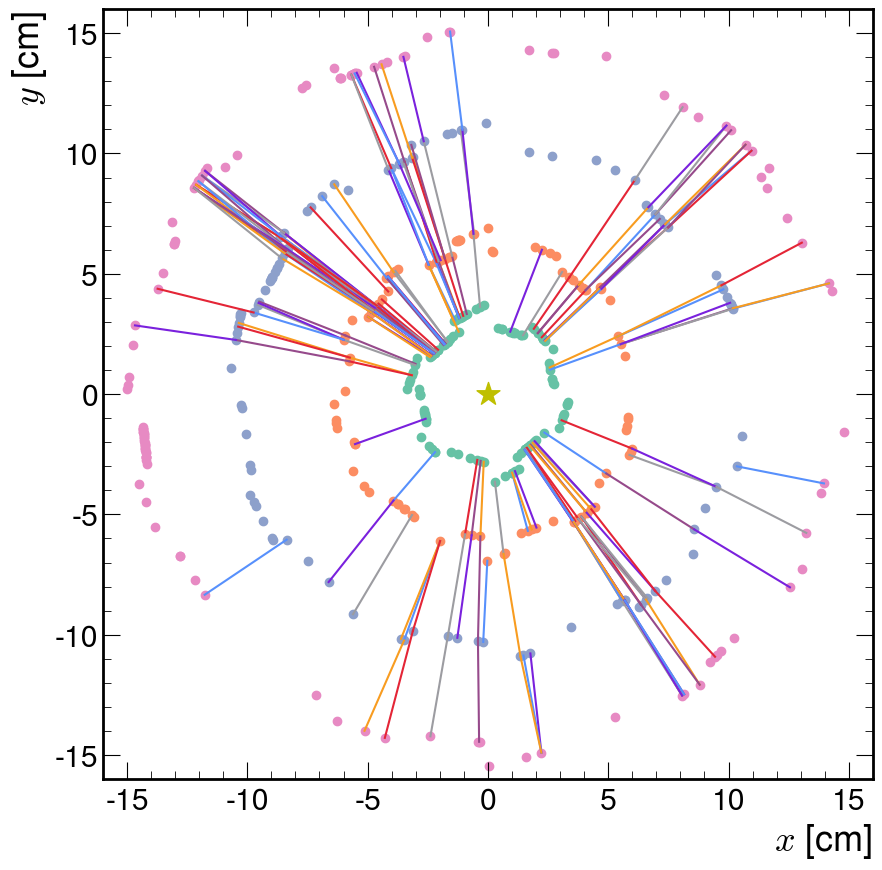

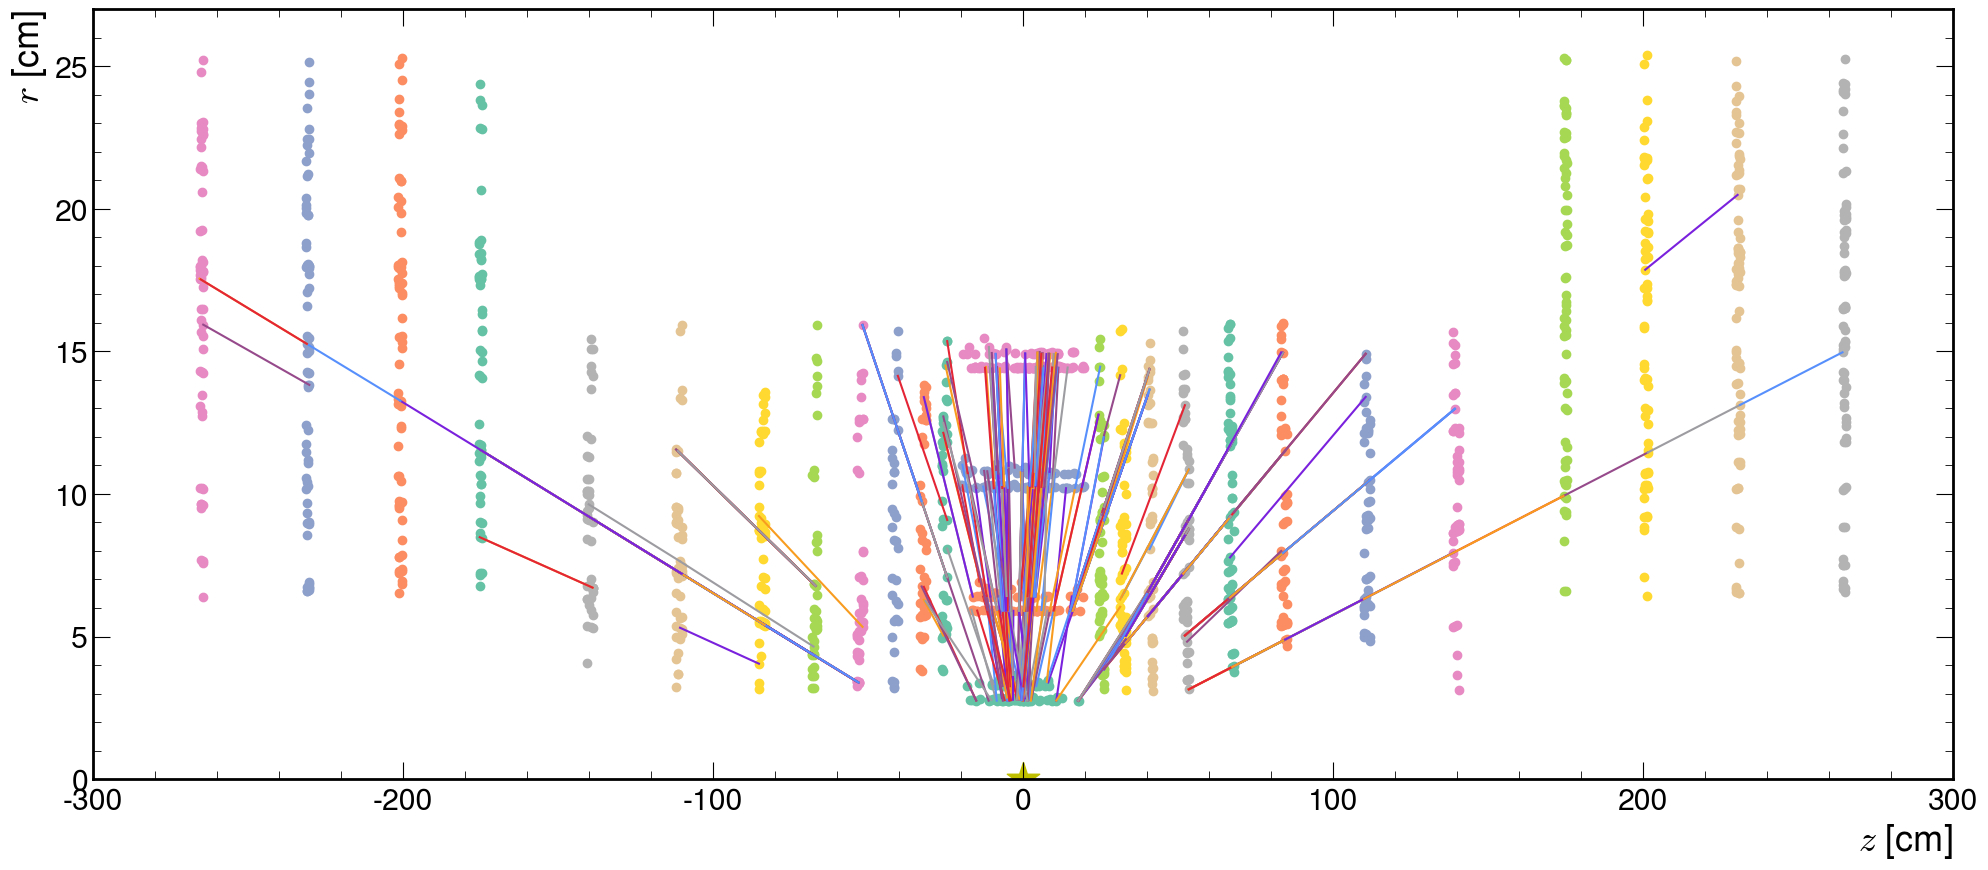

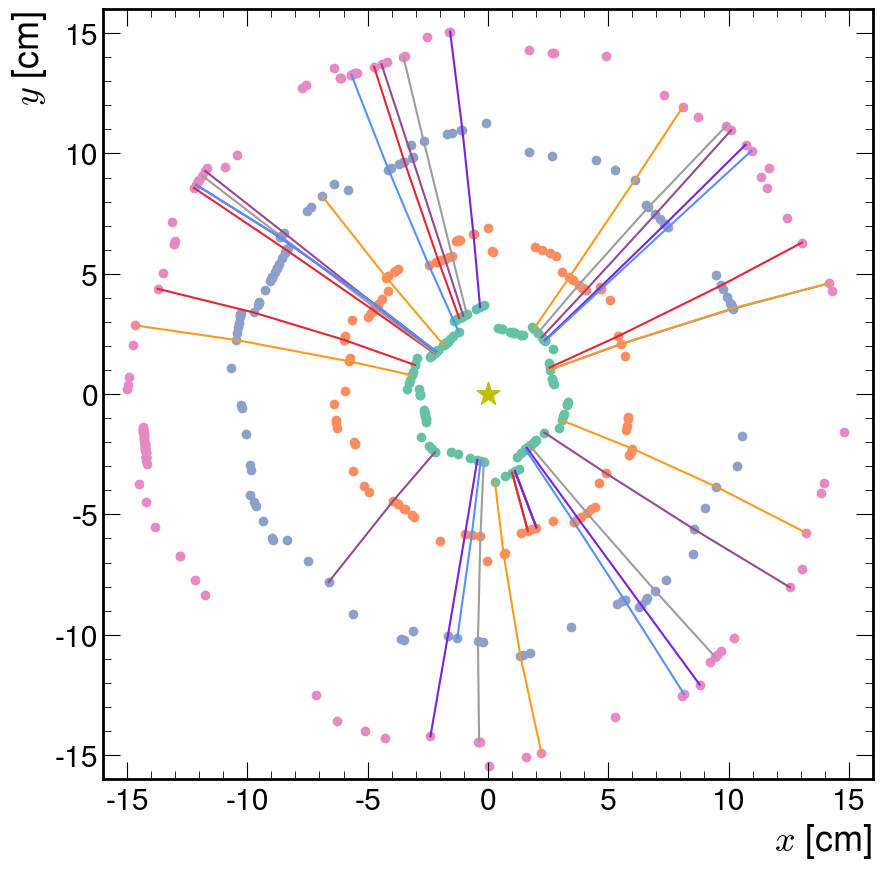

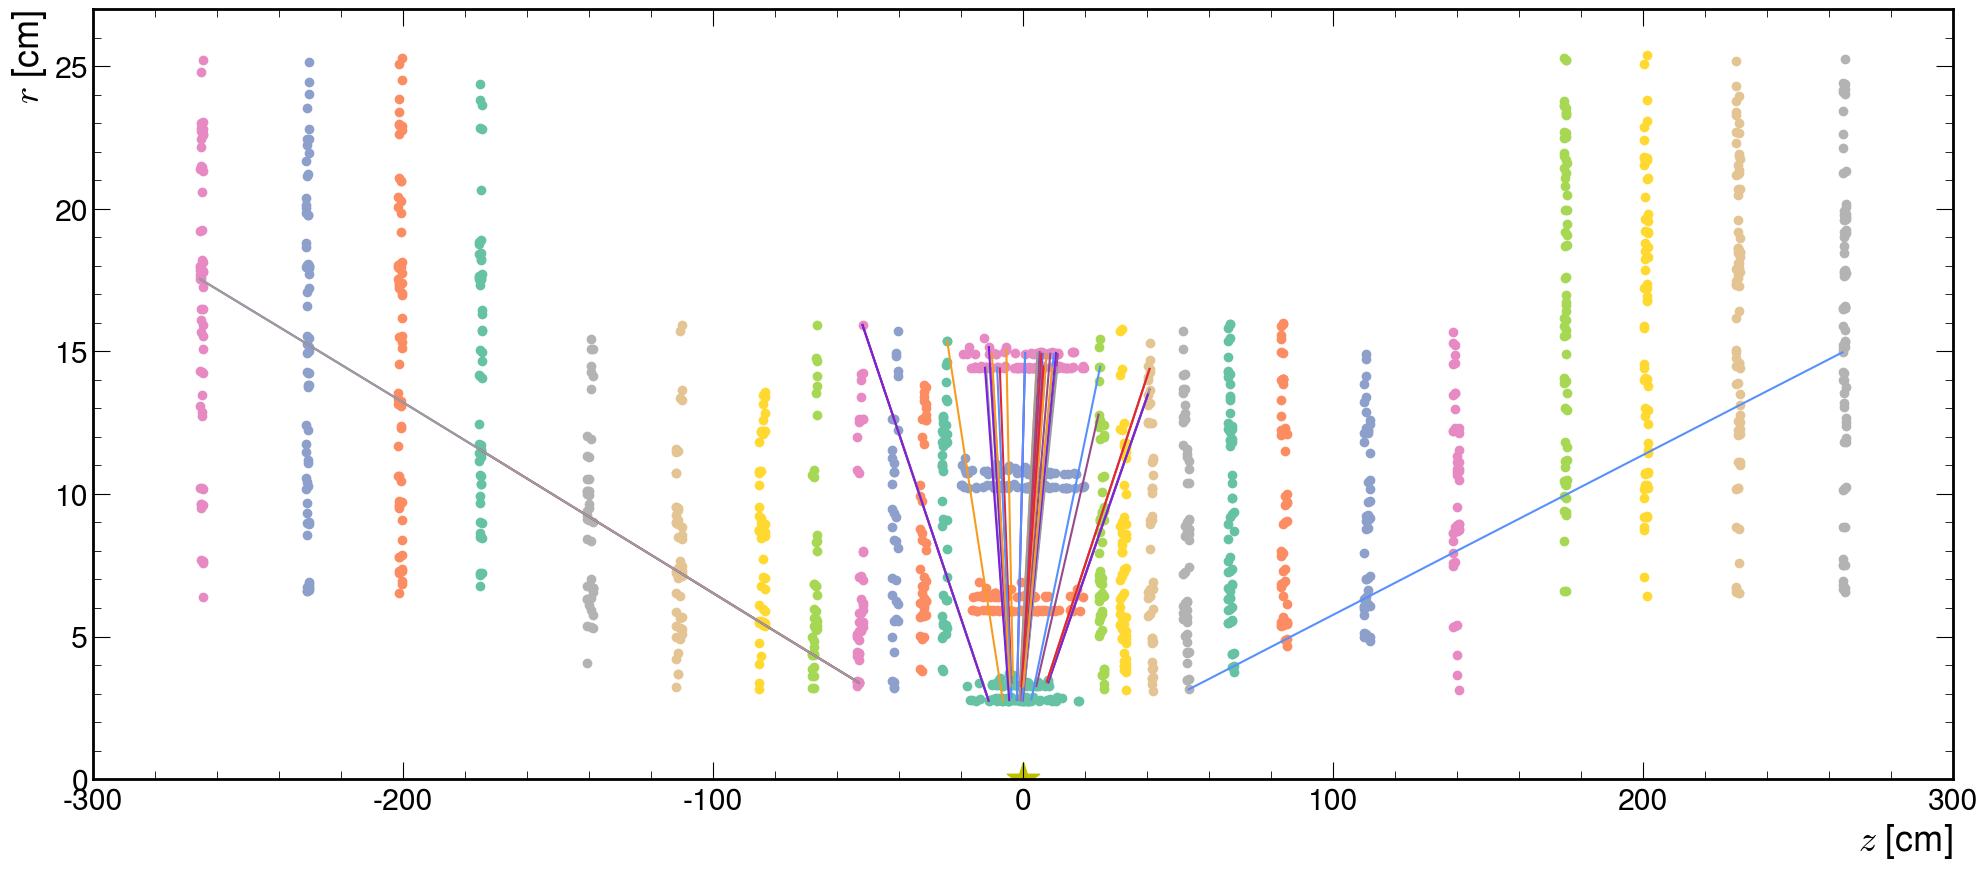

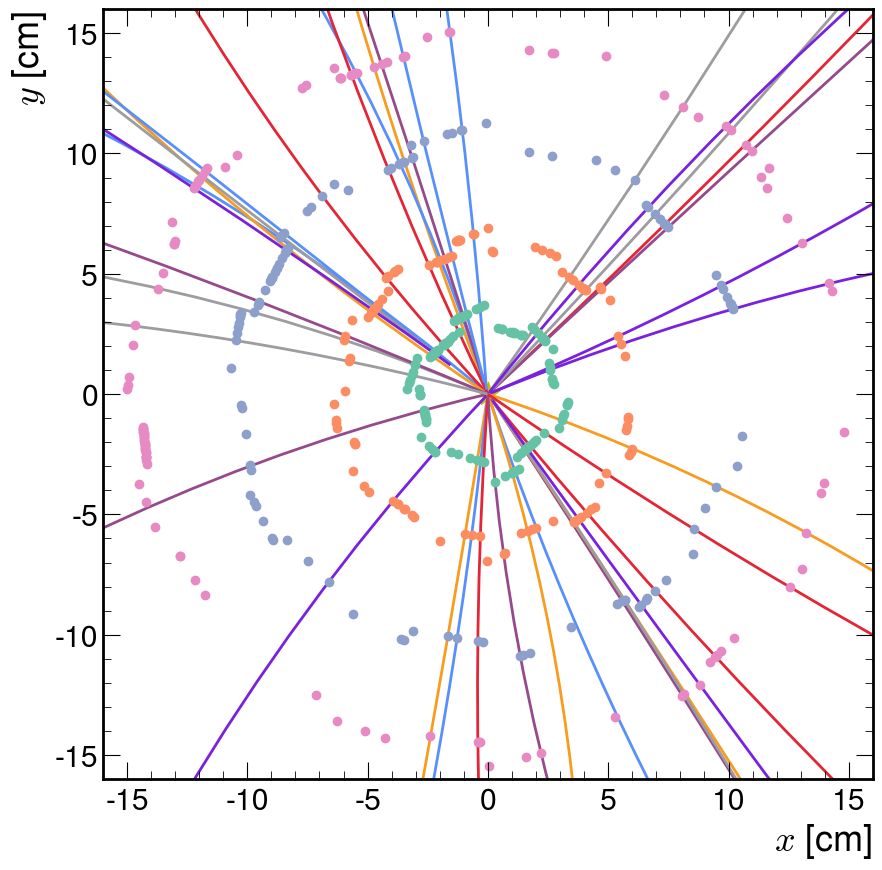

/tmp/ipykernel_501/1576218884.py:21: RuntimeWarning: invalid value encountered in arccos
  abs((np.arccos((xmax-x_center) / abs(ρ))-α0) / fxy) if (abs(ρ)>xmax) else 1000,  # out of bounce +x direction
/tmp/ipykernel_501/1576218884.py:22: RuntimeWarning: invalid value encountered in arcsin
  abs((np.arcsin((xmax-x_center) / abs(ρ))-α0) / fxy) if (abs(ρ)>xmax) else 1000,  # out of bounce +y direction


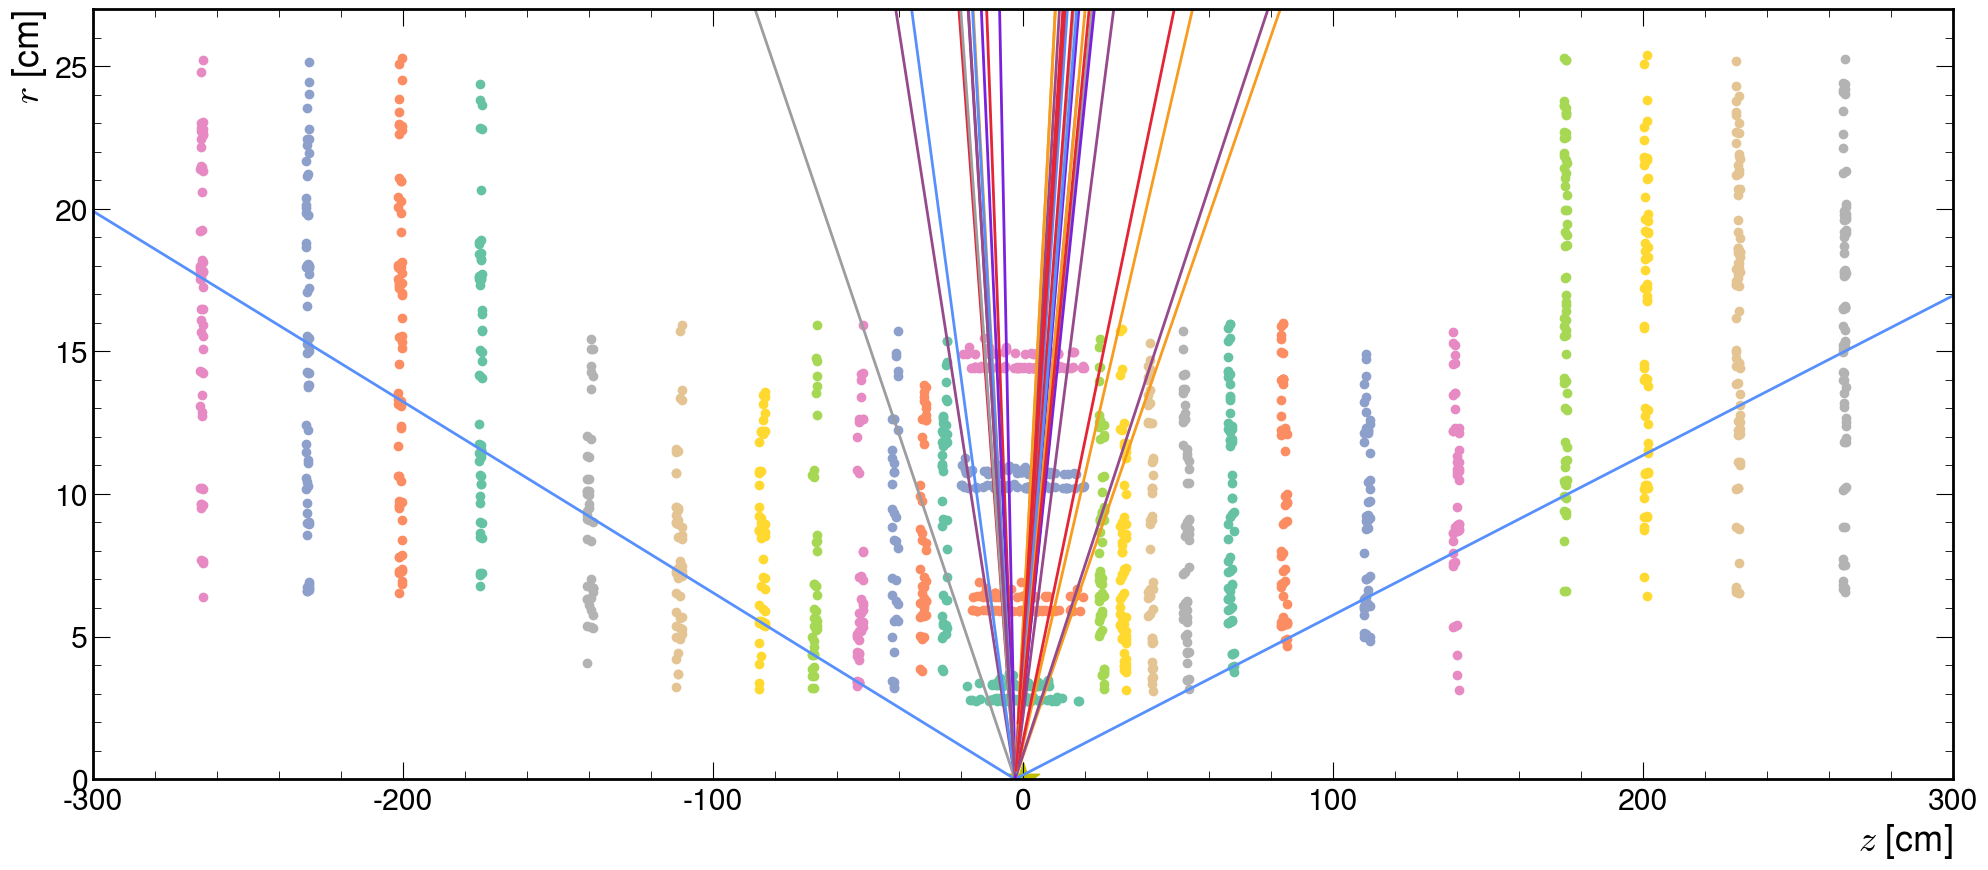

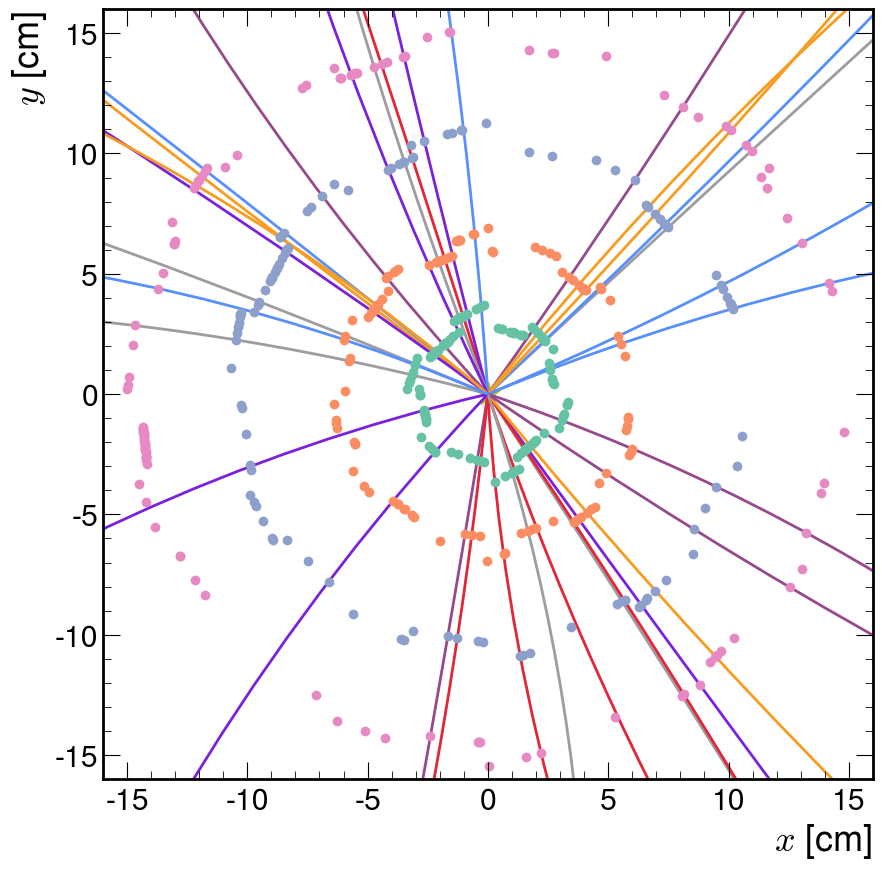

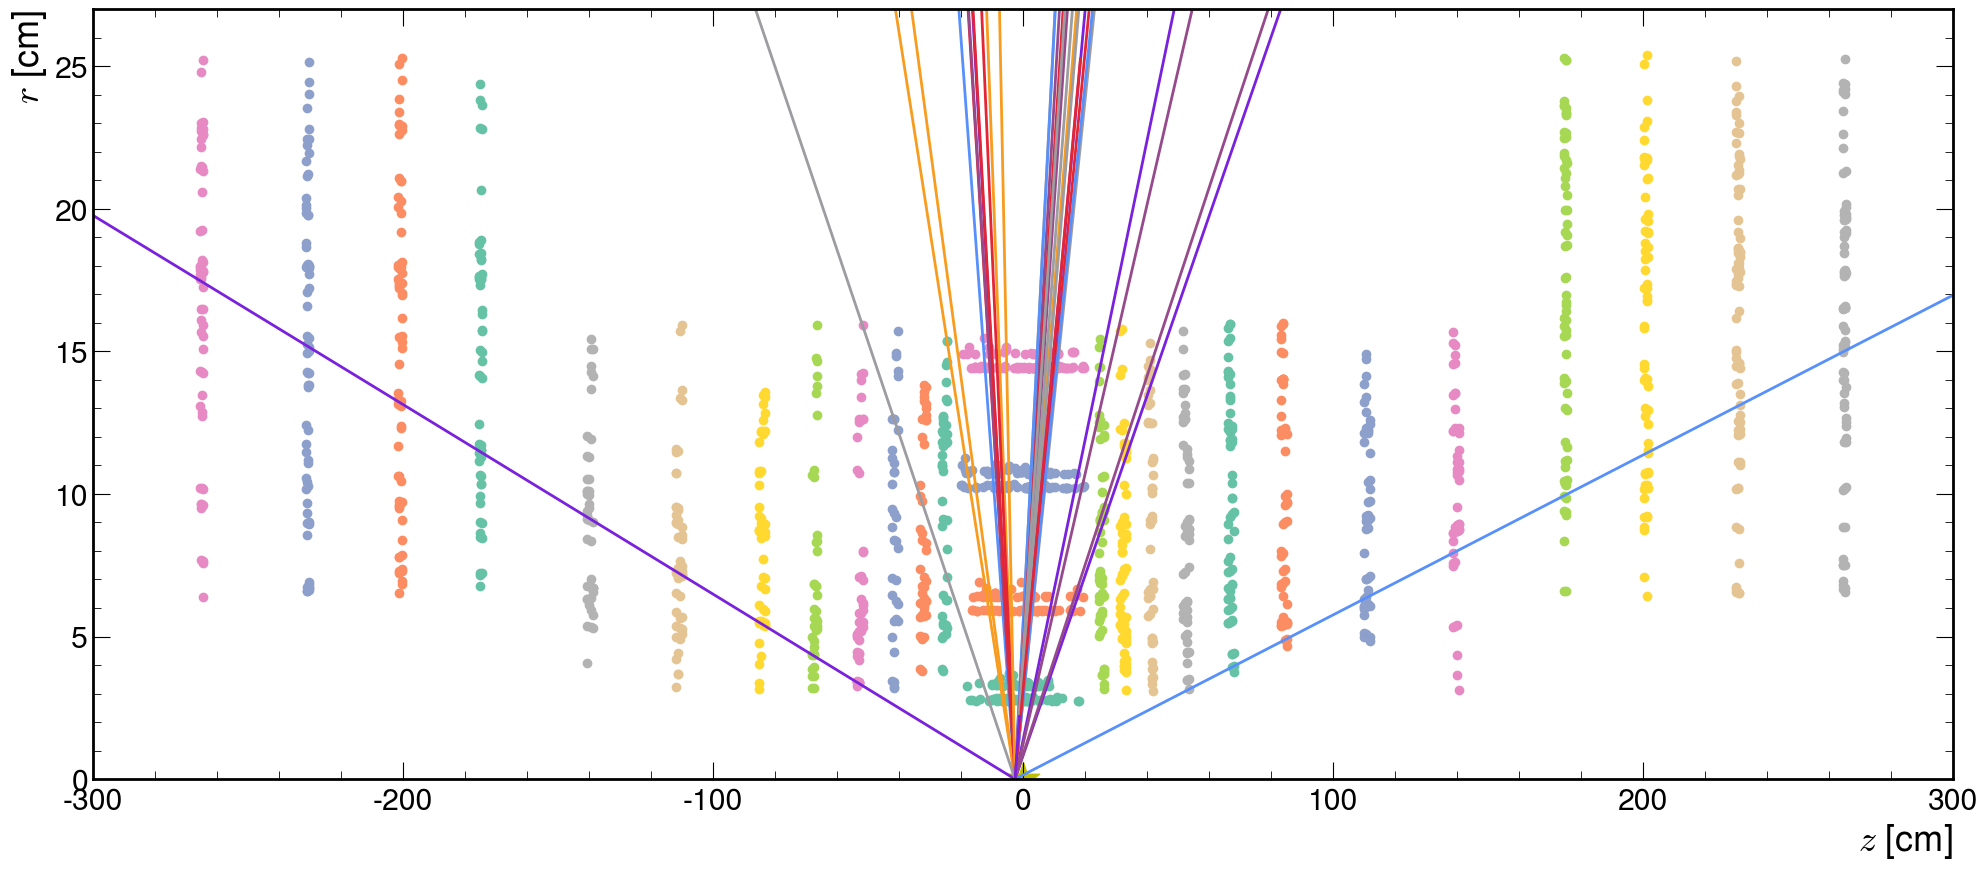

In [15]:
plotEventDisplayXY(plotDoublets=True)
plotEventDisplayRZ(plotDoublets=True)
plotEventDisplayXY(plotNtuplets=True)
plotEventDisplayRZ(plotNtuplets=True)
plotEventDisplayXY(plotParticles=True)
plotEventDisplayRZ(plotParticles=True)
plotEventDisplayXY(plotTracks=True)
plotEventDisplayRZ(plotTracks=True)

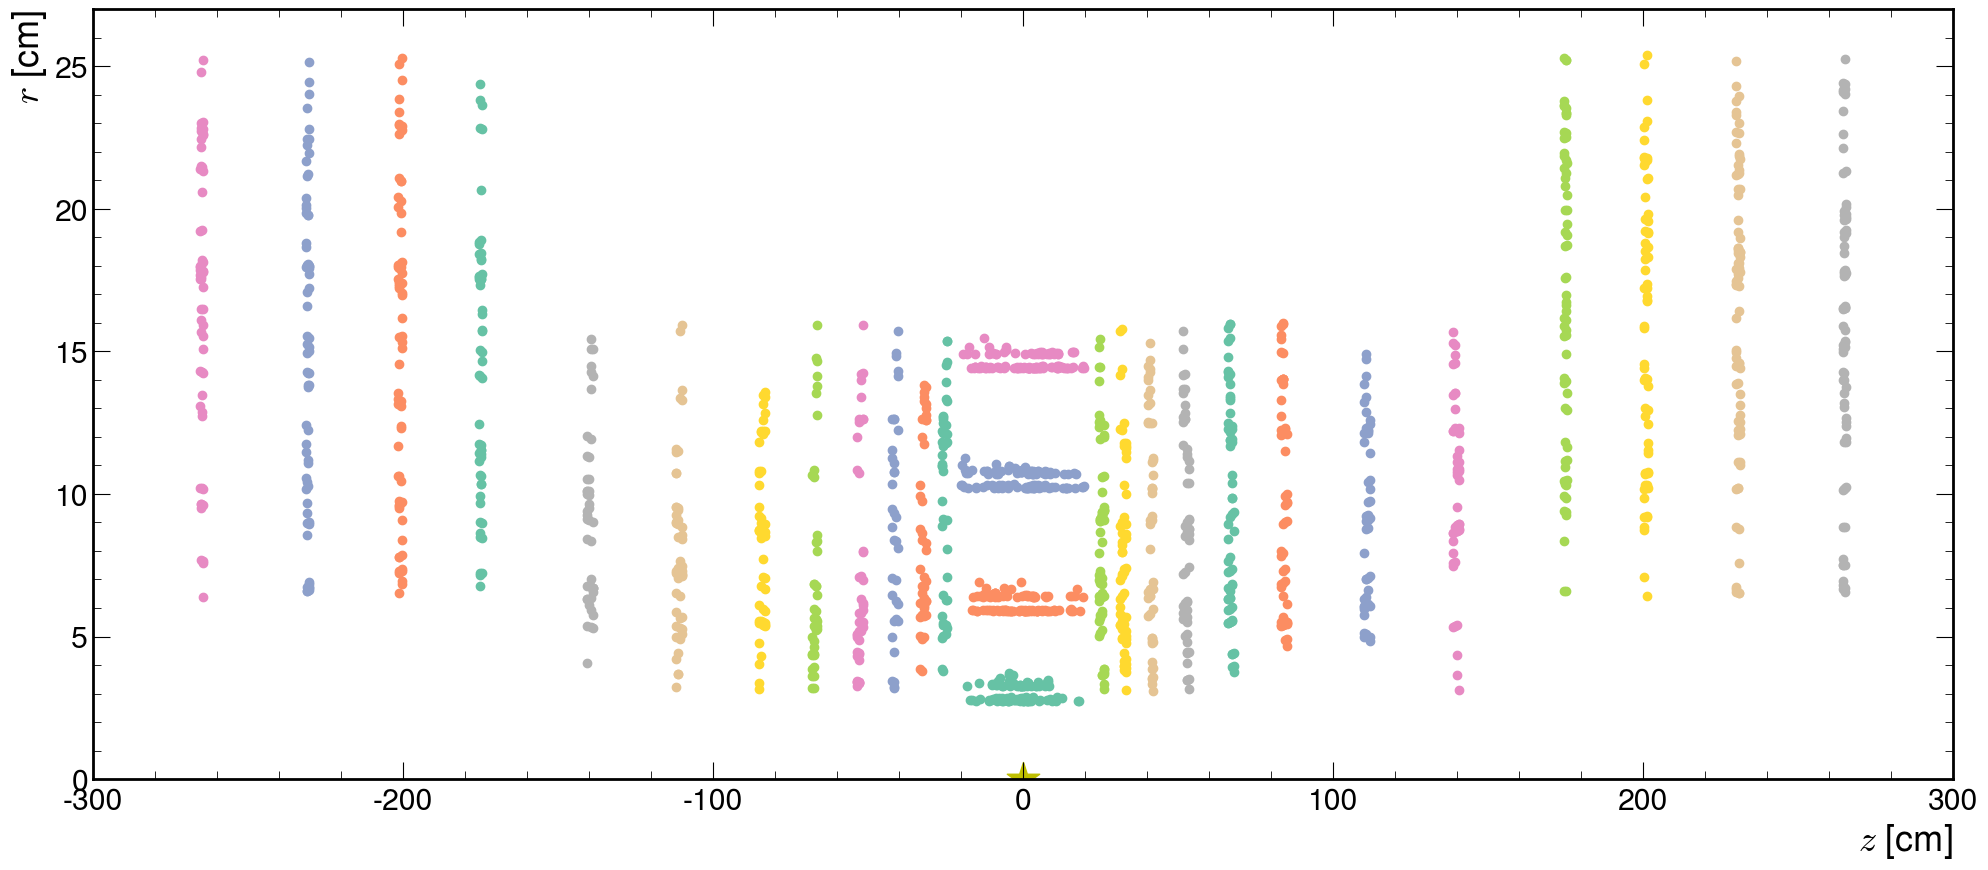

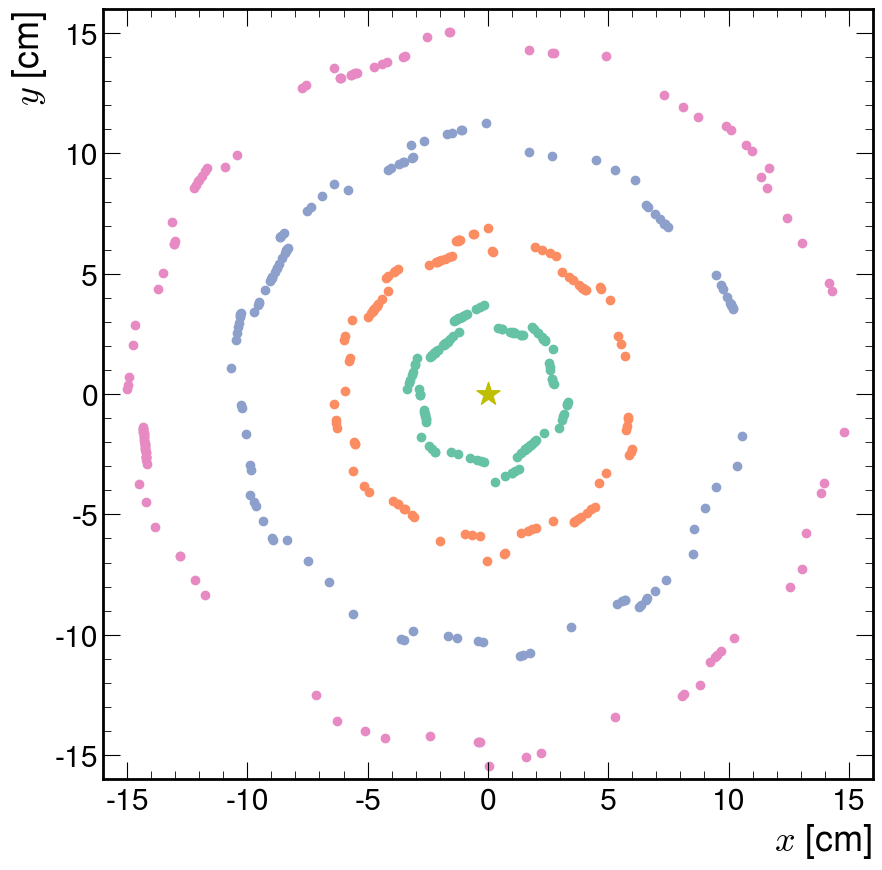

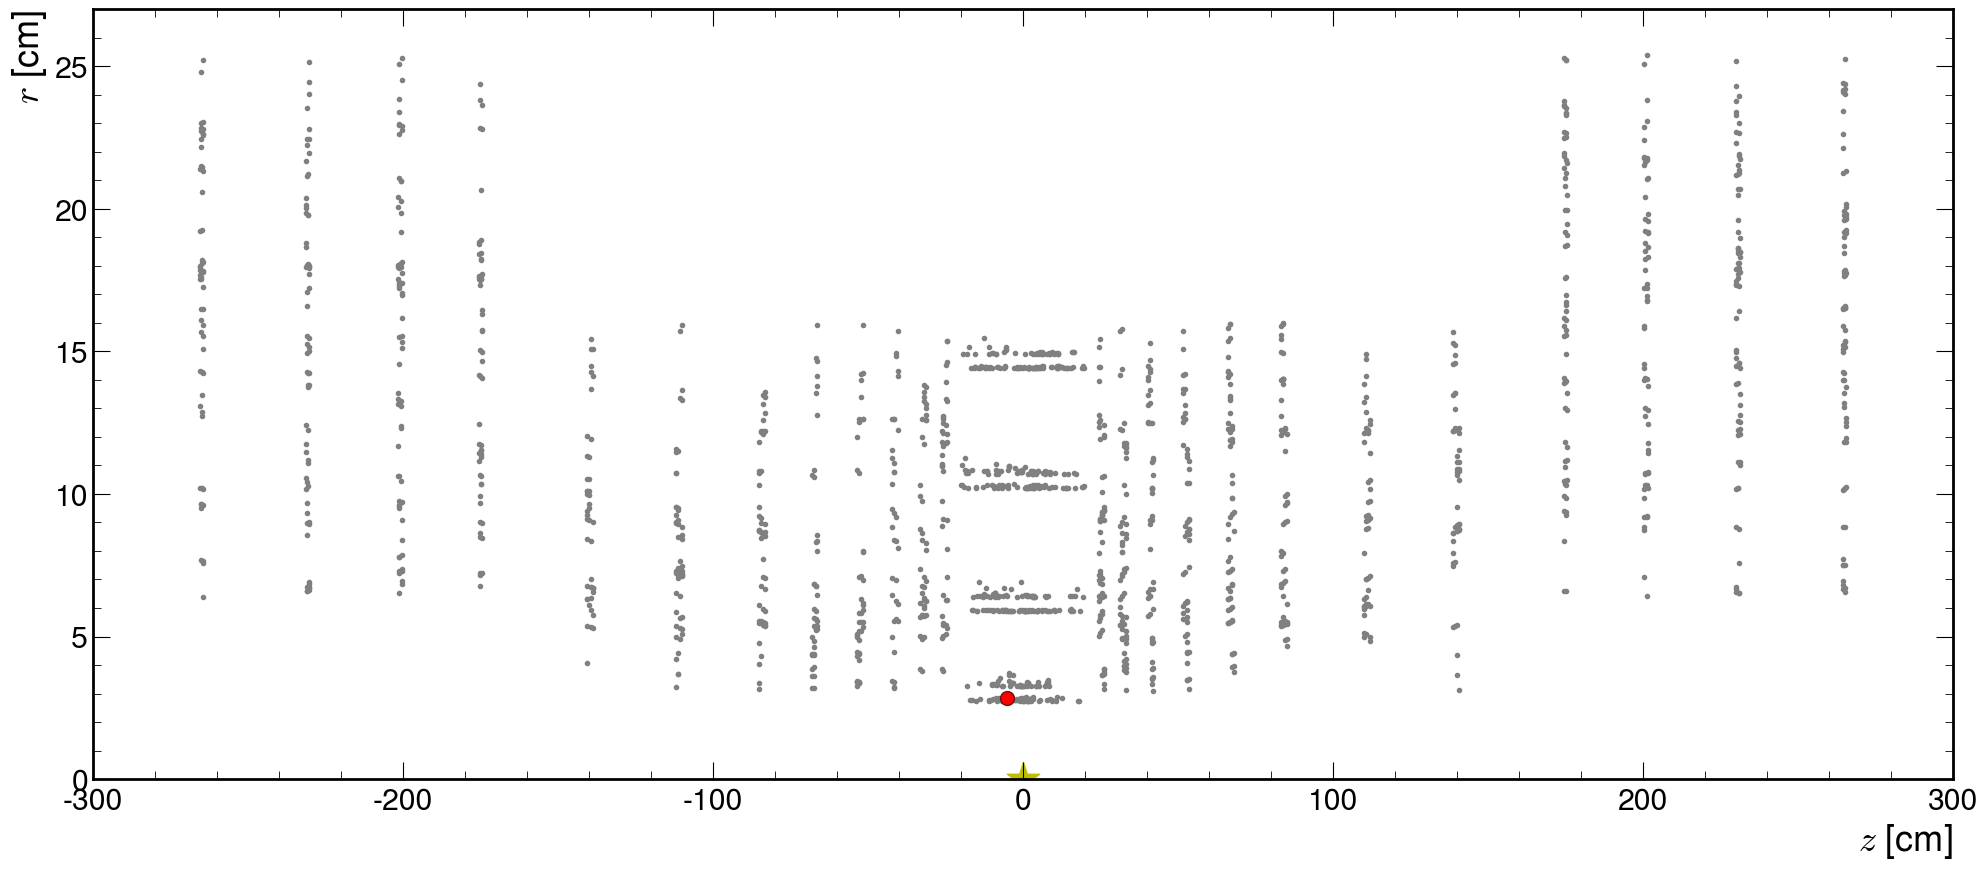

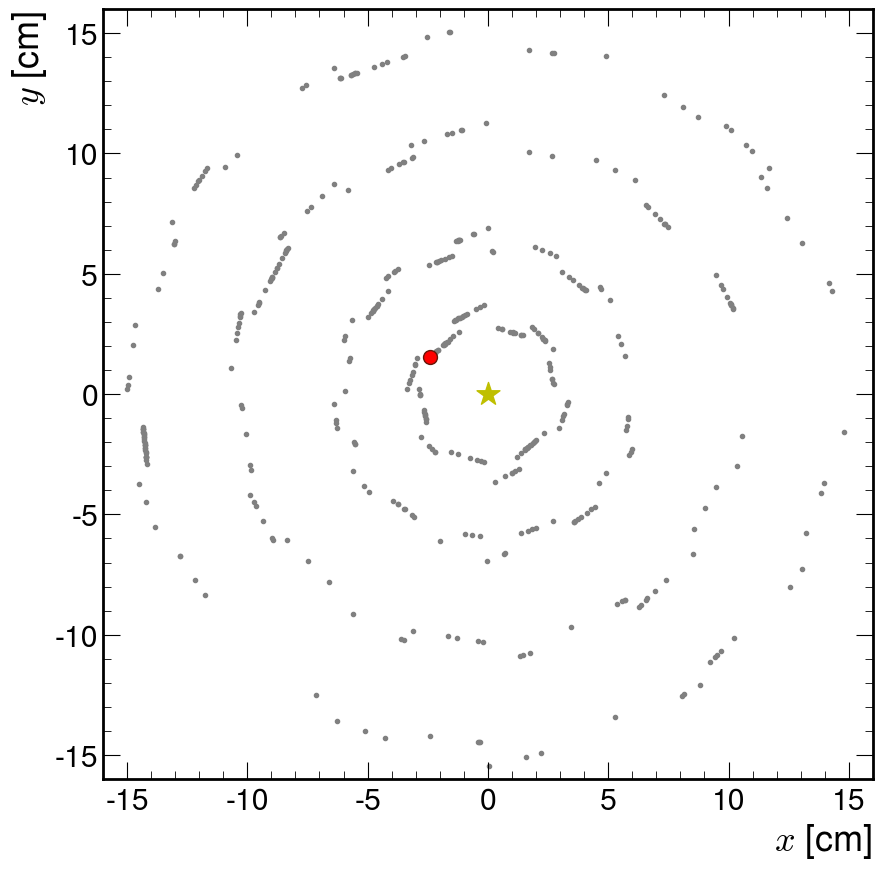

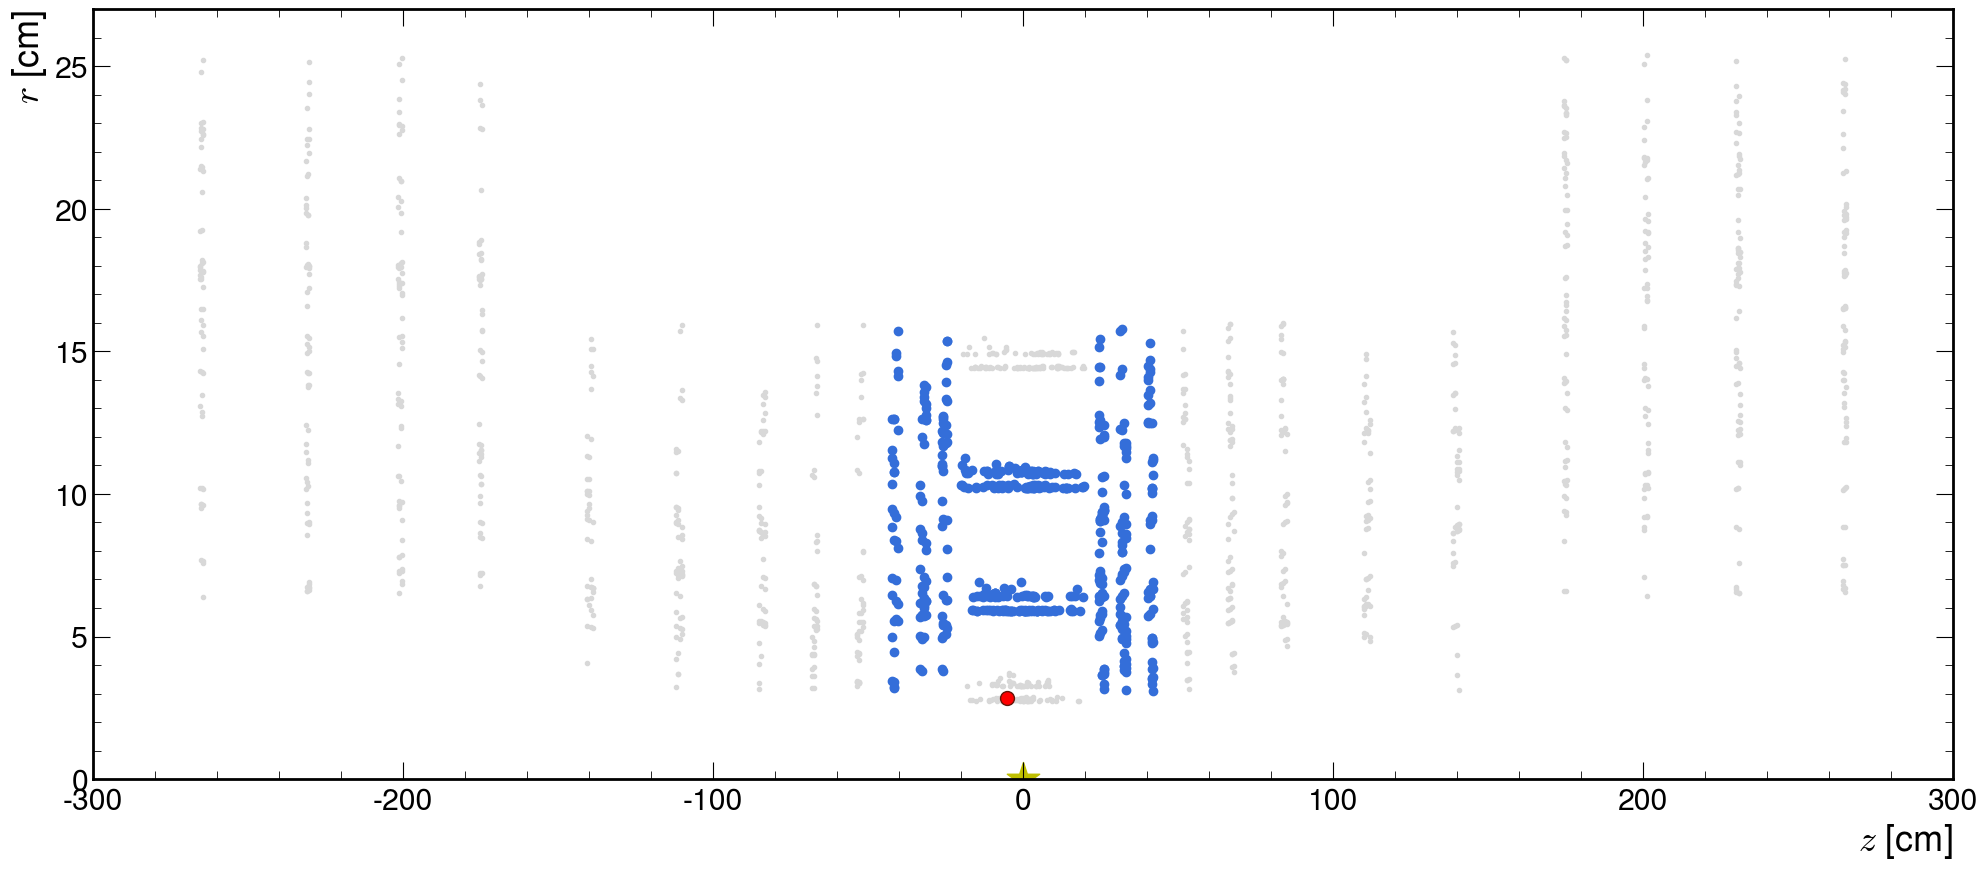

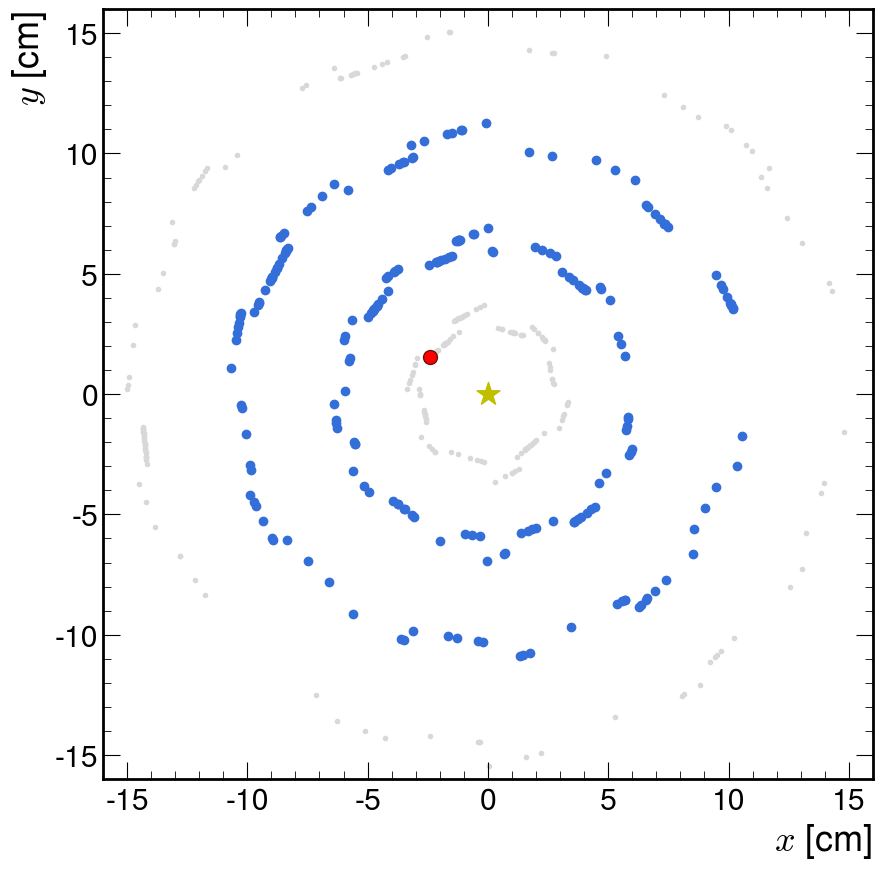

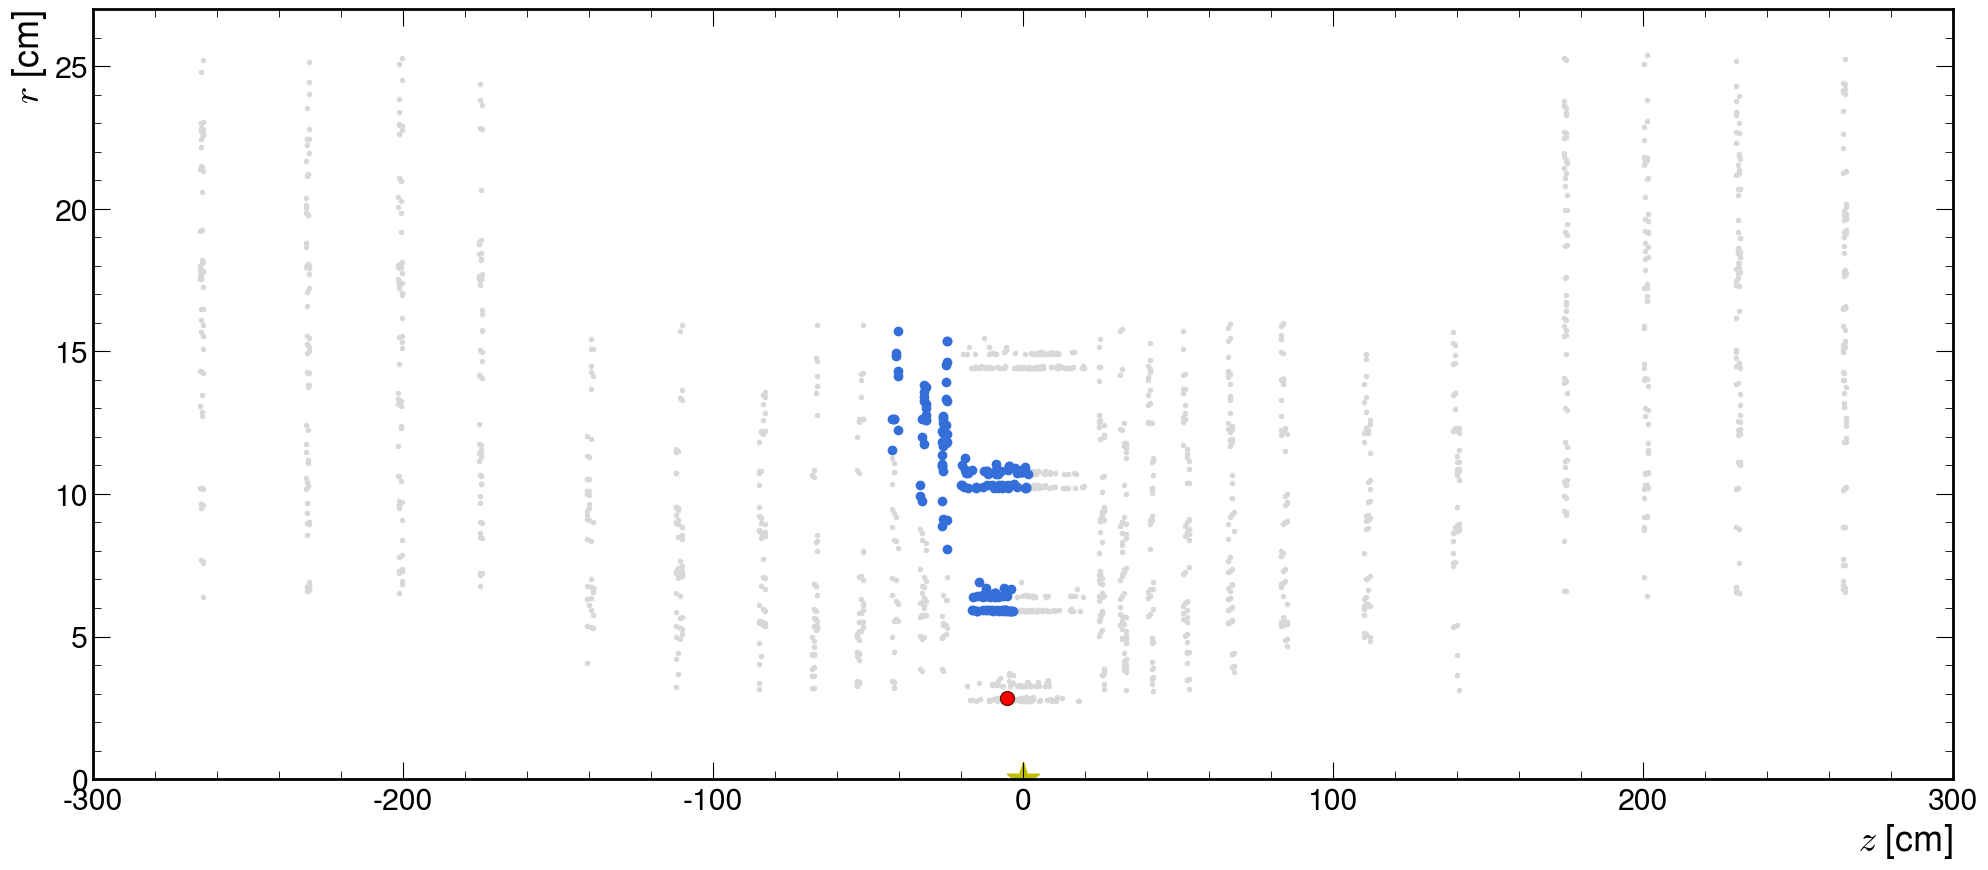

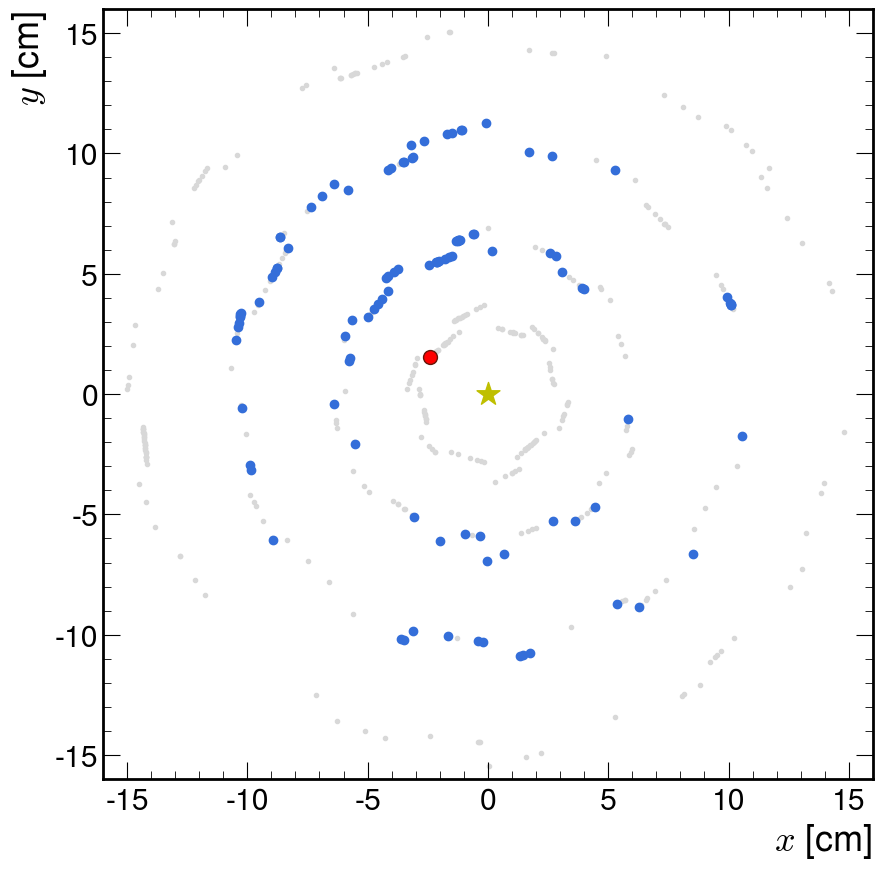

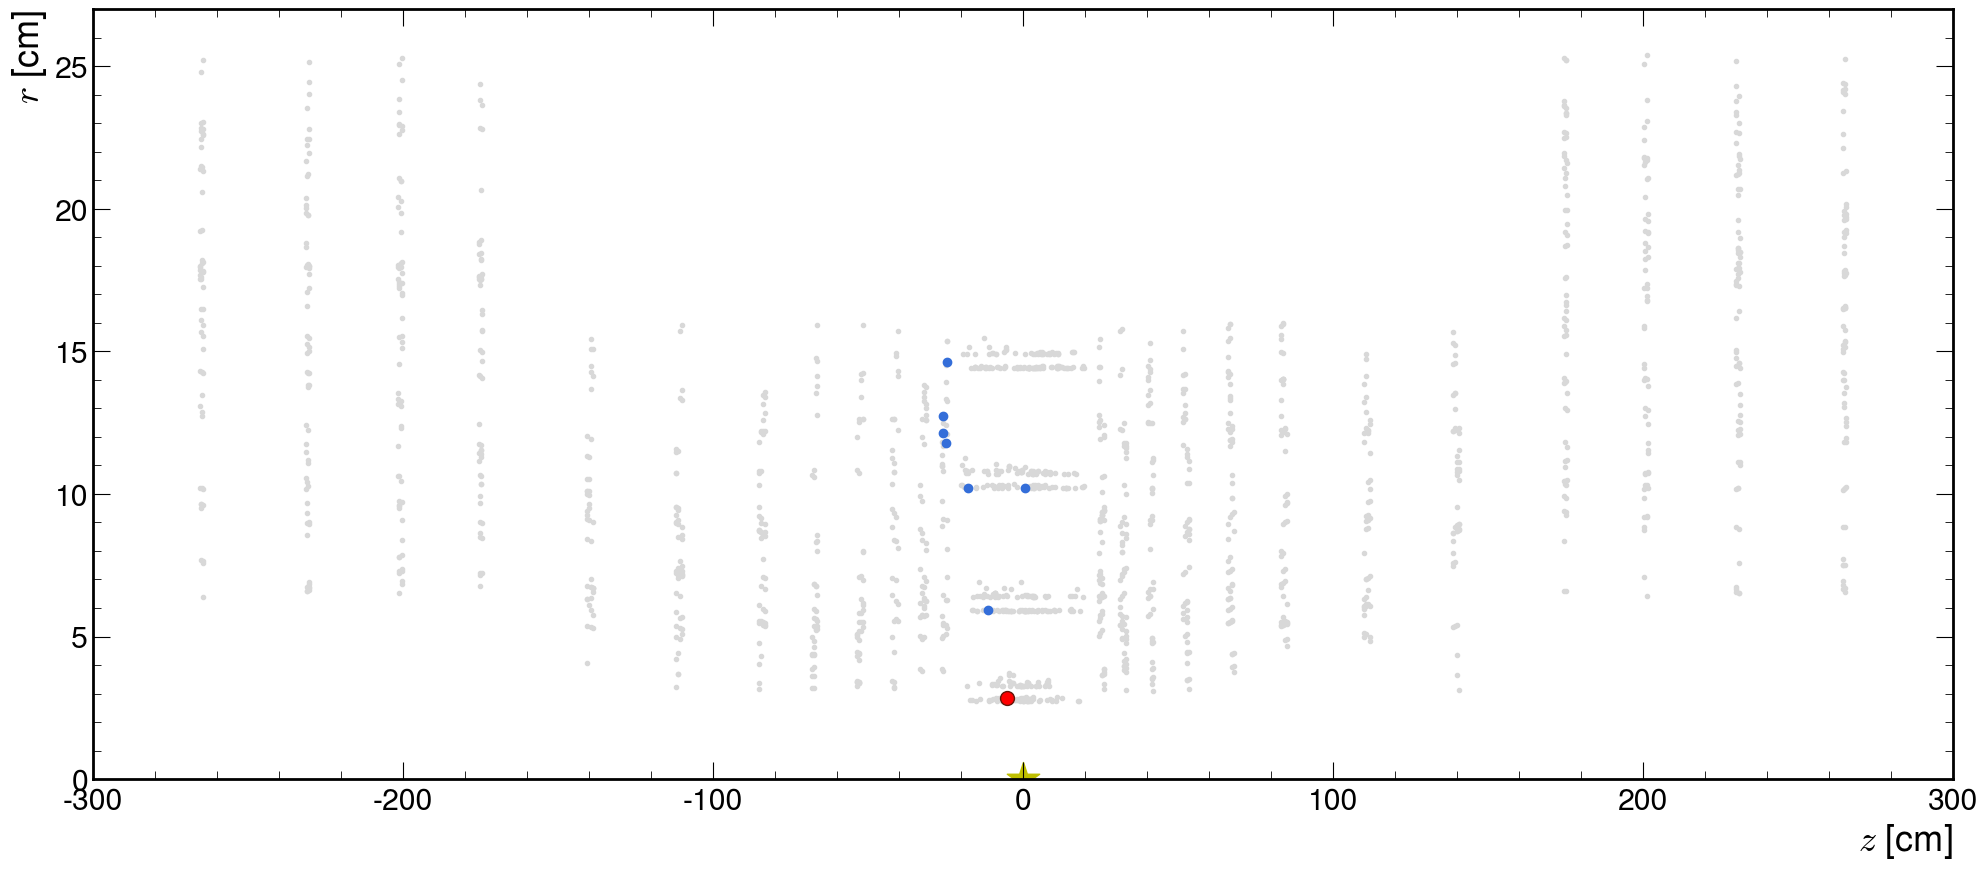

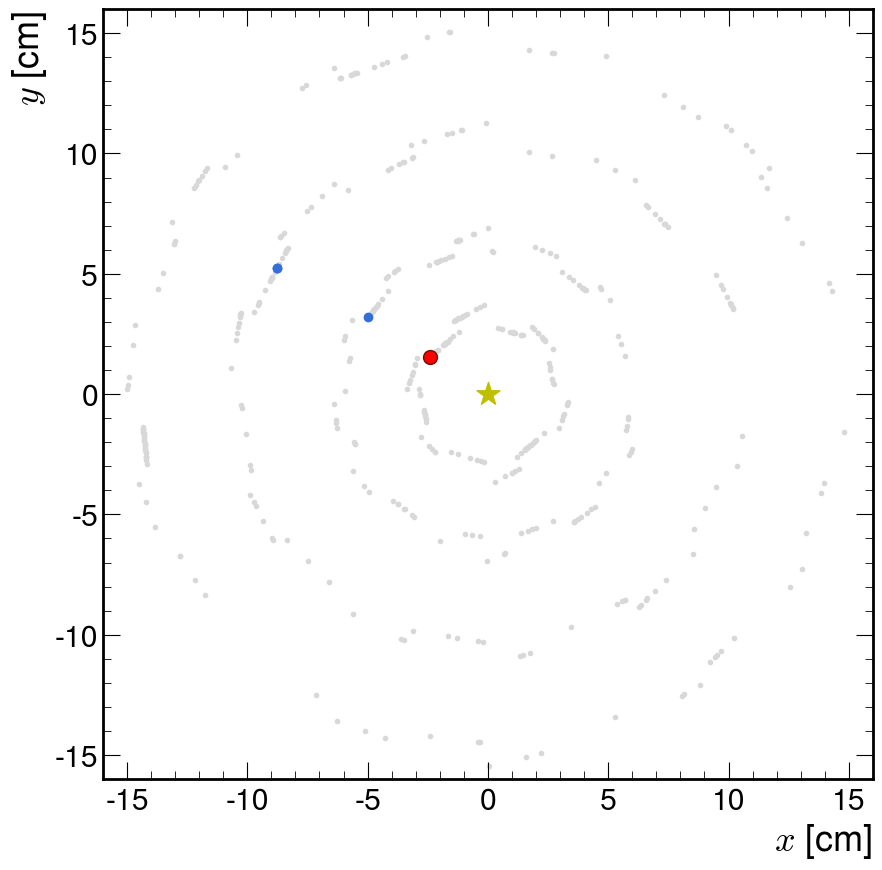

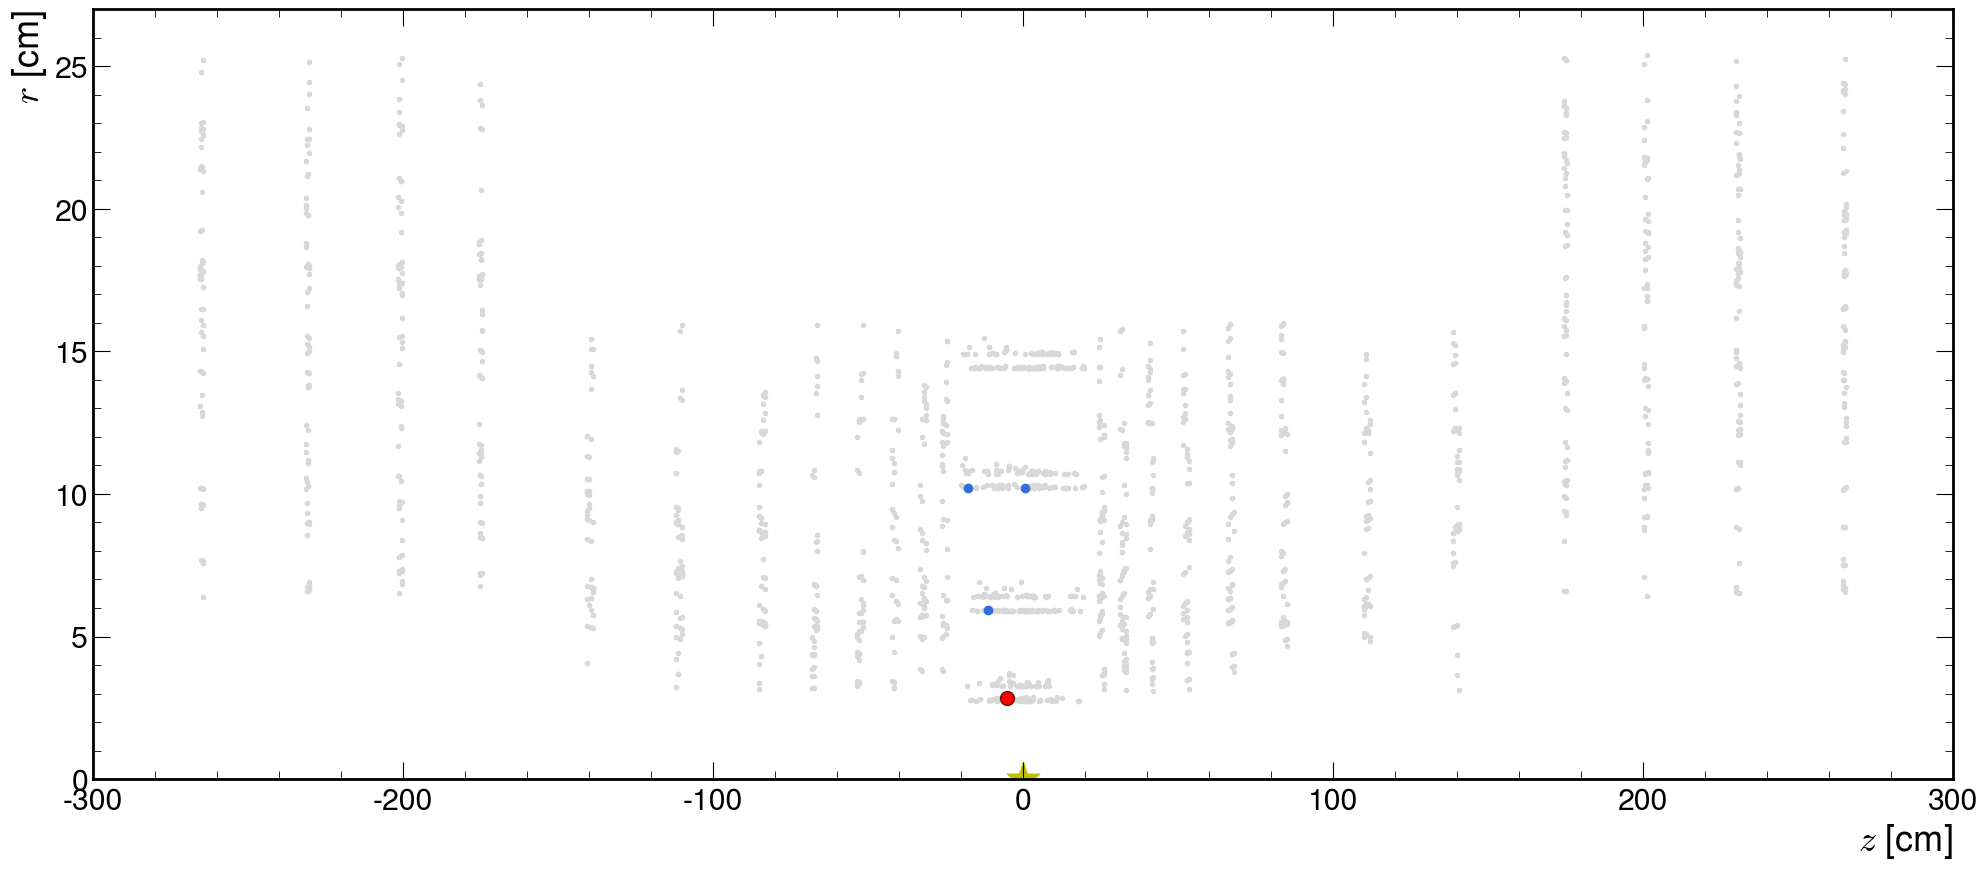

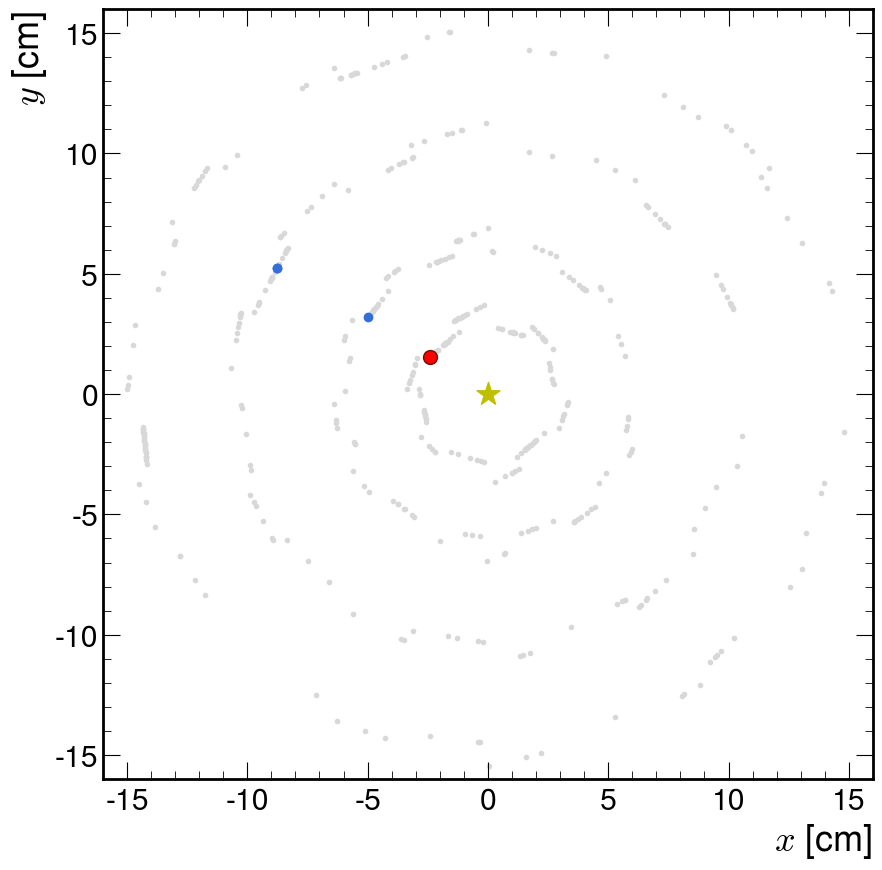

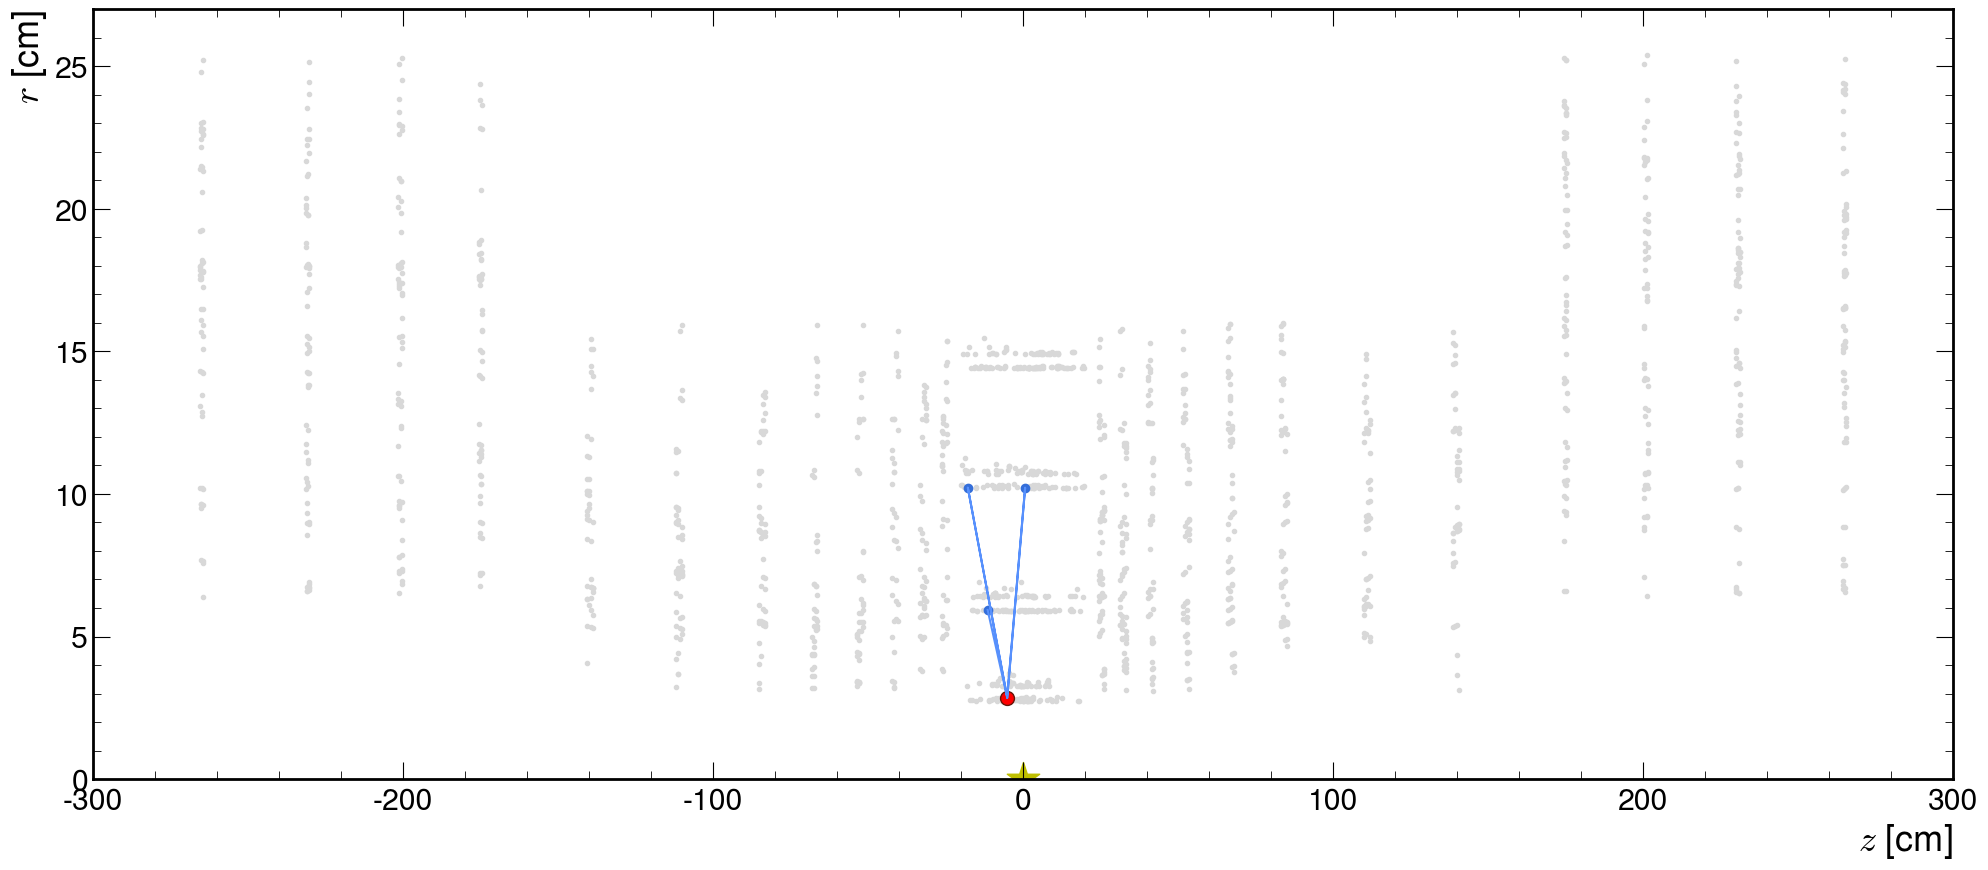

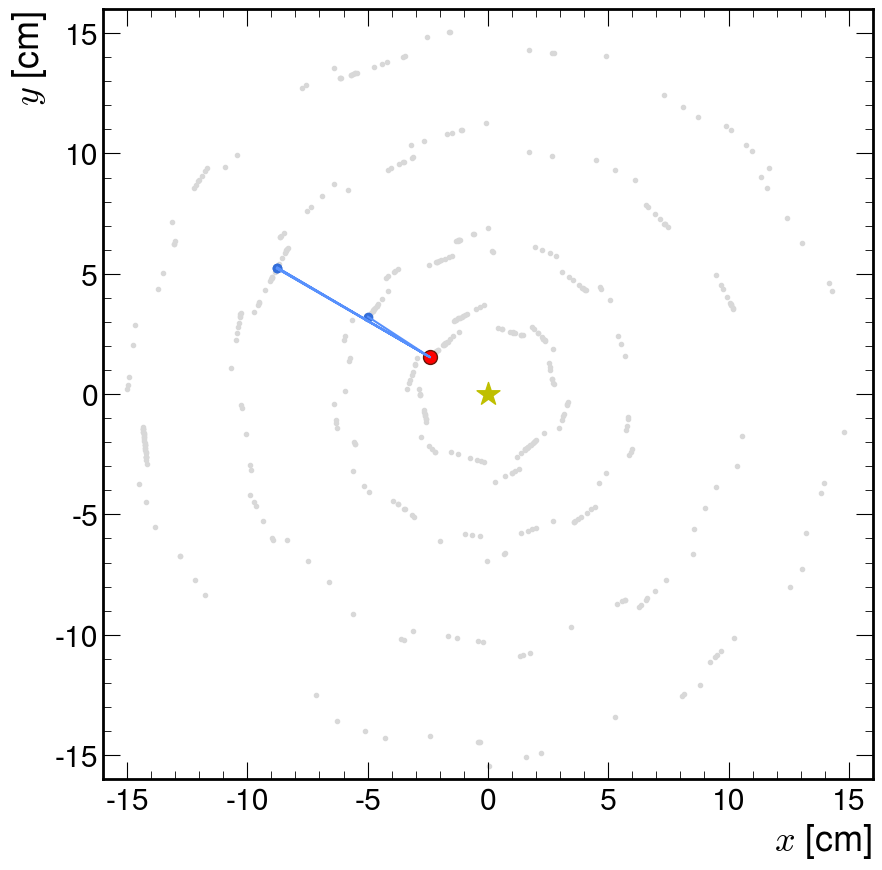

In [16]:
ihit = 50

plotEventDisplayCuts(ihit)